# Star Ratings for Medicare Plans

Rebuilds the CMS contract star ratings from the published measure data, then
breaks down what moved each rating from one year to the next.

The purpose of this document is to develop and prove a method that will predict
contract star ratings for companies in the Medicare sector of healthcare coverage.
We do this using the CMS-outlined procedure and their previous years of data
and attempt to make as best a fit on the calculation to their released ratings.

This matters because a moderate or large change in a parent company's aggregate 
star rating moves the stock quite a bit, since ratings drive quality bonus payments. 
A parent company's rating is the enrollment-weighted average of its contracts, 
so one large contract can carry it: when Humana's H5216 fell from 4.5 to 3.5 stars 
for 2025 — roughly 45% of its Medicare Advantage membership — the share of members in 
4+ star plans went from 94% to 25%, and the stock dropped as much as 22% in a day, near
$4bn of market value. Hence the year-over-year decomposition at the end of this
notebook: which measures, and which contracts, actually caused the move.

The CMS data tables this reads from are not bundled with the notebook. They are
published on the CMS [Part C and D Performance Data](https://www.cms.gov/medicare/health-drug-plans/part-c-d-performance-data) page,
one Star Ratings Data Table zip per year.

[Humana's 2024 drop](https://www.washingtonpost.com/business/2024/10/02/humana-stock-plunge-ratings/) ·
[2026 Star Ratings fact sheet](https://www.cms.gov/files/document/2026-star-ratings-fact-sheet.pdf)

## Loading the data tables

The CMS files come with either one header row or three (domain / measure / date
range). `StarRatings` reads both shapes, drops empty columns, stamps each file
with its year, and splits the cut point ranges into MIN and MAX columns.

The data we care about comes in six files per year:

`Measure Data` - Contains raw "scoring" values for each measure for each contract, which we bucket into stars using the cut point files.

`Measure Stars` - Contains the star values recorded for each measure for each contract by CMS. There are some deviations in the simple cut point bucketing calculations we did vs what this file contains, so it's interesting to look at.

`CAI` - Contains the Categorical Adjustment Index values for each contract, which are added to or subtracted from each contract's raw rating based on its share of members who are low income subsidy / dual eligible or disabled.

`Part C & Part D Cut Points` - Contains ranges for each measure that categorize a contract's score for a measure into its proper star. Used in conjunction with `Measure Data`.

`Summary` - Contains the final star rating verdict for each contract by CMS. Used to test our procedure's accuracy.

In [49]:
import os
import re
from typing import List, Optional

import numpy as np
import pandas as pd


class StarRatings:
    """Read and clean the CMS Star Ratings data tables.

    Two file shapes are supported: single-row headers, and the 3-row headers
    (domain / measure / date range) used by the Measure and Cut Point tables.
    """

    def __init__(self,
                 file_paths: Optional[List[str]] = None,
                 multirow_header_files: Optional[List[str]] = None,
                 cutpoint_files: Optional[List[str]] = None,
                 output_dir: Optional[str] = None,
                 output_cleaned: bool = True,
                 fast_clean: bool = True,
                 add_year: bool = True,
                 manual_year: Optional[int] = None,
                 process_cutpoints: bool = True):
        self.file_paths = file_paths or []
        self.cutpoint_files = cutpoint_files or []
        self.multirow_header_files = (multirow_header_files or []) + self.cutpoint_files
        self.output_dir = output_dir
        self.add_year = add_year
        self.manual_year = manual_year
        self.process_cutpoints = process_cutpoints
        self.dfs = {}

        if fast_clean and (self.file_paths or self.multirow_header_files):
            self.clean_dfs()

        if output_cleaned:
            self.save_cleaned_files()

    @staticmethod
    def _key(path: str) -> str:
        return os.path.basename(path).replace('.csv', '')

    def read_all_files(self):
        self.dfs = {}

        for path in self.file_paths:
            self.dfs[self._key(path)] = pd.read_csv(path, encoding='windows-1252', skiprows=1)

        for path in self.multirow_header_files:
            self.dfs[self._key(path)] = self.read_3row_header_file(path)

        return self.dfs

    def read_3row_header_file(self, path: str) -> pd.DataFrame:
        """Collapse the domain / measure / date header rows into one name per column."""
        headers = pd.read_csv(path, encoding='windows-1252', skiprows=1, nrows=3, header=None)
        domain_row = headers.iloc[0].fillna('').astype(str).str.strip()
        measure_row = headers.iloc[1].fillna('').astype(str).str.strip()

        # A domain header covers every column up to the next one, so carry it forward.
        is_domain = domain_row.str.match(r'(HD|DD)')
        domains = domain_row.where(is_domain)
        domains = domains.ffill()
        domains = domains.fillna('')

        names = []
        seen = {}

        for i, (domain, header, measure) in enumerate(zip(domains, domain_row, measure_row)):
            if i == 0 and 'Org Type' in header:
                name = 'Org Type'
            elif re.match(r'[CD]\d', measure):
                if domain:
                    name = f'{domain}; {measure}'
                else:
                    name = measure
            else:
                name = header or measure or f'Column_{i}'

            if name in seen:
                seen[name] += 1
                name = f'{name}_dup{seen[name]}'
            else:
                seen[name] = 0

            names.append(name)

        return pd.read_csv(path, encoding='windows-1252', skiprows=4, header=None, names=names)

    def clean_dfs(self):
        """Drop empty columns, stamp the year, and split cut point ranges."""
        if not self.dfs:
            self.read_all_files()

        for name, df in self.dfs.items():
            empty_cols = df.columns[df.isna().all()]
            self.dfs[name] = df.drop(columns=empty_cols)

        if self.add_year:
            self.add_year_column()

        if self.process_cutpoints:
            self._process_cutpoints()

        return self.dfs

    def add_year_column(self):
        """Add a Year column taken from the filename, or from manual_year when set."""
        for name, df in self.dfs.items():
            if self.manual_year is not None:
                df.insert(0, 'Year', self.manual_year)
                continue

            year = re.match(r'(\d{4})', name)
            if year:
                df.insert(0, 'Year', int(year.group(1)))
            else:
                print(f'Could not extract year from filename: {name}')

        return self.dfs

    def save_cleaned_files(self):
        output_dir = self.output_dir or 'cleaned-data'
        os.makedirs(output_dir, exist_ok=True)

        paths = []
        for name, df in self.dfs.items():
            path = os.path.join(output_dir, f'{name} - cleaned.csv')
            df.to_csv(path, index=False, encoding='utf-8')
            paths.append(path)

        return paths

    def _process_cutpoints(self):
        """Split each cut point range into MIN/MAX columns and stars into integers."""
        for path in self.cutpoint_files:
            df = self.dfs.get(self._key(path))
            if df is None:
                continue

            for col in df.columns.tolist():
                if re.match(r'(HD|DD)\d+', col):
                    bounds = df[col].map(self._parse_range).tolist()
                    df[f'{col}; MIN'] = [bound[0] for bound in bounds]
                    df[f'{col}; MAX'] = [bound[1] for bound in bounds]
                    df.drop(columns=col, inplace=True)
                elif 'stars' in col.lower():
                    df[col] = df[col].map(self._parse_stars)

    @staticmethod
    def _parse_stars(stars_str: str) -> int:
        return int(re.search(r'\d+', stars_str).group())

    @staticmethod
    def _parse_range(range_str: str):
        """Turn a range such as '> 0.76 to <= 1.39' into (lower, upper) bounds."""
        numbers = [float(n) for n in re.findall(r'-?\d+\.?\d*', range_str)]

        if len(numbers) == 2:
            return numbers[0], numbers[1]

        if len(numbers) == 1:
            if '<' in range_str:
                return np.nan, numbers[0]
            return numbers[0], np.nan

        return np.nan, np.nan

In [50]:
star_ratings_files = {
    2026: {
        'singlerow_headers': [
            '2026 Star Ratings Data Table - CAI (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Disenrollment Reasons (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Domain Stars (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - High Performing Contracts (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Low Performing Contracts (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Summary Ratings (Oct 8 2025).csv'
        ],
        'multirow_headers': [
            '2026 Star Ratings Data Table - Measure Data (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Measure Stars (Oct 8 2025).csv'
        ],
        'cutpoints': [
            '2026 Star Ratings Data Table - Part C Cut Points (Oct 8 2025).csv',
            '2026 Star Ratings Data Table - Part D Cut Points (Oct 8 2025).csv'
        ],
        'directory': 'data/2026_data/'
    },
    2025: {
        'singlerow_headers': [
            '2025 Star Ratings Data Table - CAI (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Disenrollment Reasons (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Domain Stars (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - High Performing Contracts (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Low Performing Contracts (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Summary Ratings (Dec 2 2024).csv'
        ],
        'multirow_headers': [
            '2025 Star Ratings Data Table - Measure Data (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Measure Stars (Dec 2 2024).csv'
        ],
        'cutpoints': [
            '2025 Star Ratings Data Table - Part C Cut Points (Dec 2 2024).csv',
            '2025 Star Ratings Data Table - Part D Cut Points (Dec 2 2024).csv'
        ],
        'directory': 'data/2025_data/'
    },
    2024: {
        'singlerow_headers': [
            '2024 Star Ratings Data Table - CAI (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Disenrollment Reasons (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Domain Stars (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - High Performing Contracts (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Low Performing Contracts (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Summary Rating (Jul 2 2024).csv'
        ],
        'multirow_headers': [
            '2024 Star Ratings Data Table - Measure Data (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Measure Stars (Jul 2 2024).csv'
        ],
        'cutpoints': [
            '2024 Star Ratings Data Table - Part C Cut Points (Jul 2 2024).csv',
            '2024 Star Ratings Data Table - Part D Cut Points (Jul 2 2024).csv'
        ],
        'directory': 'data/2024_data/'
    }
}

In [51]:
def year_paths(year, key):
    year_files = star_ratings_files[year]
    return [year_files['directory'] + name for name in year_files[key]]


all_singlerow = []
all_multirow = []
all_cutpoints = []

for year in star_ratings_files:
    all_singlerow.extend(year_paths(year, 'singlerow_headers'))
    all_multirow.extend(year_paths(year, 'multirow_headers'))
    all_cutpoints.extend(year_paths(year, 'cutpoints'))

SR = StarRatings(
    file_paths=all_singlerow,
    multirow_header_files=all_multirow,
    cutpoint_files=all_cutpoints,
    output_cleaned=False
)

In [52]:
cai_24 = SR.dfs['2024 Star Ratings Data Table - CAI (Jul 2 2024)']
cai_25 = SR.dfs['2025 Star Ratings Data Table - CAI (Dec 2 2024)']
cai_26 = SR.dfs['2026 Star Ratings Data Table - CAI (Oct 8 2025)']
cai_dfs = [cai_24, cai_25, cai_26]

measure_data_24 = SR.dfs['2024 Star Ratings Data Table - Measure Data (Jul 2 2024)']
measure_data_25 = SR.dfs['2025 Star Ratings Data Table - Measure Data (Dec 2 2024)']
measure_data_26 = SR.dfs['2026 Star Ratings Data Table - Measure Data (Oct 8 2025)']
measure_data_dfs = [measure_data_24, measure_data_25, measure_data_26]

measure_stars_24 = SR.dfs['2024 Star Ratings Data Table - Measure Stars (Jul 2 2024)']
measure_stars_25 = SR.dfs['2025 Star Ratings Data Table - Measure Stars (Dec 2 2024)']
measure_stars_26 = SR.dfs['2026 Star Ratings Data Table - Measure Stars (Oct 8 2025)']
measure_stars_dfs = [measure_stars_24, measure_stars_25, measure_stars_26]

partc_cutpoints_24 = SR.dfs['2024 Star Ratings Data Table - Part C Cut Points (Jul 2 2024)']
partc_cutpoints_25 = SR.dfs['2025 Star Ratings Data Table - Part C Cut Points (Dec 2 2024)']
partc_cutpoints_26 = SR.dfs['2026 Star Ratings Data Table - Part C Cut Points (Oct 8 2025)']
partc_cutpoints_dfs = [partc_cutpoints_24, partc_cutpoints_25, partc_cutpoints_26]

partd_cutpoints_24 = SR.dfs['2024 Star Ratings Data Table - Part D Cut Points (Jul 2 2024)']
partd_cutpoints_25 = SR.dfs['2025 Star Ratings Data Table - Part D Cut Points (Dec 2 2024)']
partd_cutpoints_26 = SR.dfs['2026 Star Ratings Data Table - Part D Cut Points (Oct 8 2025)']
partd_cutpoints_dfs = [partd_cutpoints_24, partd_cutpoints_25, partd_cutpoints_26]

summary_24 = SR.dfs['2024 Star Ratings Data Table - Summary Rating (Jul 2 2024)']
summary_25 = SR.dfs['2025 Star Ratings Data Table - Summary Ratings (Dec 2 2024)']
summary_26 = SR.dfs['2026 Star Ratings Data Table - Summary Ratings (Oct 8 2025)']
summary_df = pd.concat([summary_24, summary_25, summary_26], ignore_index=True)

## Reference tables

Two hand-maintained lookups: the weight CMS gives each measure (with a separate
column for Puerto Rico contracts), and the CAI value each FAC score maps to.

In [53]:
measure_weights_df = pd.read_csv('data/other_data/Measure Weights Union.csv')
measure_weights_df = measure_weights_df.rename(columns={'Category ID': 'measure_code', 'Weight': 'Non PR Weight'})
measure_weights_df['Year'] = measure_weights_df['Year'].astype(int)
measure_weights_df['SNP Measure'] = measure_weights_df['SNP Measure'].astype(bool)

measure_weights_df.head(3)

,Year,measure_code,Weighting Category,Non PR Weight,PR Weight,SNP Measure
0,2025,D05,Patients' Experience and Complaints Measure,4.0,4.0,False
1,2025,C02,Process Measure,1.0,1.0,False
2,2025,D06,Patients' Experience and Complaints Measure,4.0,4.0,False


In [54]:
cai_mappings = pd.read_csv('data/other_data/CAI value map.csv').rename(columns={'year': 'Year'})

cai_mappings.head()

,Year,scope,FAC,cai_value
0,2025,Overall,1,-0.058127
1,2025,Overall,2,-0.033597
2,2025,Overall,3,-0.014802
3,2025,Overall,4,0.002506
4,2025,Overall,5,0.045230


In [55]:
# One column per CAI scope, keyed on Year + FAC
cai_mappings_pivot = cai_mappings.pivot_table(
    index=['Year', 'FAC'],
    columns='scope',
    values='cai_value',
    aggfunc='first'
).reset_index()
cai_mappings_pivot.columns.name = None

scope_names = {}
for col in cai_mappings_pivot.columns:
    if col not in ('Year', 'FAC'):
        scope_names[col] = f'{col} CAI Mapped Value'

cai_mappings_pivot = cai_mappings_pivot.rename(columns=scope_names)

cai_mappings_pivot.head()

,Year,FAC,MA-PD Part D Summary CAI Mapped Value,Overall CAI Mapped Value,PDP Part D Summary CAI Mapped Value,Part C Summary CAI Mapped Value
0,2024,1,-0.035219,-0.024917,-0.317950,-0.003487
1,2024,2,-0.018599,-0.001531,-0.172794,0.006987
2,2024,3,0.009901,0.016703,-0.139296,0.022797
3,2024,4,0.034454,0.036199,-0.067530,0.044588
4,2024,5,0.079744,0.067616,0.043919,0.066880


## Cut points

The cut point tables arrive one column per measure and one row per star. These
cells reshape them to one row per measure with a `star_1` ... `star_5` range,
pull out the numeric threshold behind each range, and work out which direction
the measure runs in. `stars_from_cutpoints` then scores any measure value.

In [56]:
def group_cutpoint_columns(df):
    """Pair the '<domain>; <code>: <name>; MIN' and '; MAX' columns up by measure."""
    measures = {}

    for col in df.columns:
        parts = col.split('; ')
        if len(parts) < 3:
            continue

        bound = parts[2].strip()
        if bound not in ('MIN', 'MAX'):
            continue

        code, _, name = parts[1].partition(':')
        code = code.strip()
        full_measure = f'{parts[0]}; {code}: {name.strip()}'

        if full_measure not in measures:
            measures[full_measure] = {'measure_code': code}

        measures[full_measure][bound] = col

    return measures


def format_range(lower, upper):
    """Render a pair of bounds as '35.0-69.0', '≤48.0' or '≥96.0'."""
    ranges = pd.Series(None, index=lower.index, dtype=object)

    ranges[lower.notna() & upper.notna()] = lower.astype(str) + '-' + upper.astype(str)
    ranges[lower.isna() & upper.notna()] = '≤' + upper.astype(str)
    ranges[lower.notna() & upper.isna()] = '≥' + lower.astype(str)

    return ranges


def pivot_cutpoints_step1(cutpoints_dfs, rating_category):
    """Reshape cut points to one row per year, measure and star, with a range string."""
    frames = []

    for df in cutpoints_dfs:
        if 'Org Type' in df.columns:
            org_type = df['Org Type']
        else:
            org_type = 'MA'

        for full_measure, measure in group_cutpoint_columns(df).items():
            if 'MIN' not in measure or 'MAX' not in measure:
                continue

            frames.append(pd.DataFrame({
                'year': df['Year'],
                'rating_category': rating_category,
                'org_type': org_type,
                'star': df['Number of Stars Displayed on the Plan Finder Tool'],
                'full_measures': full_measure,
                'measure_code': measure['measure_code'],
                'ranges': format_range(df[measure['MIN']], df[measure['MAX']])
            }))

    return pd.concat(frames, ignore_index=True)


partc_cutpoints_step1 = pivot_cutpoints_step1(partc_cutpoints_dfs, 'Part C')
partd_cutpoints_step1 = pivot_cutpoints_step1(partd_cutpoints_dfs, 'Part D')
cutpoints_step1 = pd.concat([partc_cutpoints_step1, partd_cutpoints_step1], ignore_index=True)

cutpoints_step1.head(10)

,year,rating_category,org_type,star,full_measures,measure_code,ranges
0,2024,Part C,MA,1,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,≤48.0
1,2024,Part C,MA,2,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,48.0-63.0
2,2024,Part C,MA,3,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,63.0-71.0
3,2024,Part C,MA,4,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,71.0-79.0
4,2024,Part C,MA,5,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,≥79.0
5,2024,Part C,MA,1,"HD1: Staying Healthy: Screenings, Tests and Va...",C02,≤48.0
6,2024,Part C,MA,2,"HD1: Staying Healthy: Screenings, Tests and Va...",C02,48.0-60.0
7,2024,Part C,MA,3,"HD1: Staying Healthy: Screenings, Tests and Va...",C02,60.0-71.0
8,2024,Part C,MA,4,"HD1: Staying Healthy: Screenings, Tests and Va...",C02,71.0-80.0
9,2024,Part C,MA,5,"HD1: Staying Healthy: Screenings, Tests and Va...",C02,≥80.0


In [57]:
def pivot_cutpoints_step2(cutpoints_df):
    """Unpivot on star value so each measure gets a star_1 ... star_5 column."""
    index_cols = ['year', 'rating_category', 'org_type', 'measure_code', 'full_measures']

    pivoted = cutpoints_df.pivot_table(
        index=index_cols,
        columns='star',
        values='ranges',
        aggfunc='first'
    ).reset_index()

    star_names = {}
    for col in pivoted.columns:
        if col not in index_cols:
            star_names[col] = f'star_{int(col)}'

    pivoted = pivoted.rename(columns=star_names)
    pivoted.columns.name = None

    return pivoted


cutpoints_step2 = pivot_cutpoints_step2(cutpoints_step1)

cutpoints_step2.head(10)

,year,rating_category,org_type,measure_code,full_measures,star_1,star_2,star_3,star_4,star_5
0,2024,Part C,MA,C01,"HD1: Staying Healthy: Screenings, Tests and Va...",≤48.0,48.0-63.0,63.0-71.0,71.0-79.0,≥79.0
1,2024,Part C,MA,C02,"HD1: Staying Healthy: Screenings, Tests and Va...",≤48.0,48.0-60.0,60.0-71.0,71.0-80.0,≥80.0
2,2024,Part C,MA,C03,"HD1: Staying Healthy: Screenings, Tests and Va...",≤63.0,63.0-67.0,67.0-74.0,74.0-78.0,≥78.0
3,2024,Part C,MA,C04,"HD1: Staying Healthy: Screenings, Tests and Va...",≤42.0,42.0-48.0,48.0-53.0,53.0-58.0,≥58.0
4,2024,Part C,MA,C05,HD2: Managing Chronic (Long Term) Conditions; ...,≤42.0,42.0-57.0,57.0-74.0,74.0-85.0,≥85.0
5,2024,Part C,MA,C06,HD2: Managing Chronic (Long Term) Conditions; ...,≤48.0,48.0-75.0,75.0-87.0,87.0-98.0,≥98.0
6,2024,Part C,MA,C07,HD2: Managing Chronic (Long Term) Conditions; ...,≤55.0,55.0-76.0,76.0-90.0,90.0-96.0,≥96.0
7,2024,Part C,MA,C08,HD2: Managing Chronic (Long Term) Conditions; ...,≤28.0,28.0-40.0,40.0-50.0,50.0-68.0,≥68.0
8,2024,Part C,MA,C09,HD2: Managing Chronic (Long Term) Conditions; ...,≤52.0,52.0-65.0,65.0-73.0,73.0-81.0,≥81.0
9,2024,Part C,MA,C10,HD2: Managing Chronic (Long Term) Conditions; ...,≤44.0,44.0-67.0,67.0-80.0,80.0-87.0,≥87.0


In [58]:
def extract_largest_value(range_str):
    """Largest number in a range string such as '35.0-69.0', '≤48.0' or '-0.253472-0.0'."""
    if pd.isna(range_str):
        return None

    cleaned = str(range_str).replace('≤', '').replace('≥', '')
    # Space out range hyphens so they are not read as negative signs.
    cleaned = re.sub(r'(\d)-(\d)', r'\1 \2', cleaned)

    numbers = re.findall(r'-?\d+\.?\d*', cleaned)
    if not numbers:
        return None

    return max(float(num) for num in numbers)


star_cols = [col for col in cutpoints_step2.columns if col.startswith('star_')]
for col in star_cols:
    cutpoints_step2[f'{col}_max'] = cutpoints_step2[col].apply(extract_largest_value)

cutpoints_step2[['year', 'measure_code', 'star_1_max', 'star_2_max', 'star_3_max',
                 'star_4_max', 'star_5_max']].head(10)

,year,measure_code,star_1_max,star_2_max,star_3_max,star_4_max,star_5_max
0,2024,C01,48.0,63.0,71.0,79.0,79.0
1,2024,C02,48.0,60.0,71.0,80.0,80.0
2,2024,C03,63.0,67.0,74.0,78.0,78.0
3,2024,C04,42.0,48.0,53.0,58.0,58.0
4,2024,C05,42.0,57.0,74.0,85.0,85.0
5,2024,C06,48.0,75.0,87.0,98.0,98.0
6,2024,C07,55.0,76.0,90.0,96.0,96.0
7,2024,C08,28.0,40.0,50.0,68.0,68.0
8,2024,C09,52.0,65.0,73.0,81.0,81.0
9,2024,C10,44.0,67.0,80.0,87.0,87.0


In [59]:
# Rising cut points mean a higher measure value earns more stars.
cutpoints_step2['higher_is_better'] = cutpoints_step2['star_3_max'] > cutpoints_step2['star_2_max']

cutpoints_step2['higher_is_better'].value_counts()

higher_is_better
True     144
False     21
Name: count, dtype: int64

In [60]:
def stars_from_cutpoints(values, cutpoints, higher_is_better):
    """Score 1-5 stars from the four interior cut points.

    Lower-is-better measures reuse the same cut points in reverse and invert the score.
    """
    star_1 = cutpoints['star_1_max']
    star_2 = cutpoints['star_2_max']
    star_3 = cutpoints['star_3_max']
    star_4 = cutpoints['star_4_max']
    star_5 = cutpoints['star_5_max']

    ascending = np.select(
        [values < star_1, values < star_2, values < star_3, values < star_4],
        [1, 2, 3, 4],
        5
    )
    descending = 6 - np.select(
        [values < star_5, values < star_4, values < star_3, values < star_2],
        [1, 2, 3, 4],
        5
    )

    # Measures with no cut points on file fall back to the ascending scale.
    stars = np.where(higher_is_better.ne(False), ascending, descending)
    stars = pd.Series(stars, index=values.index)

    return stars.where(values.notna()).astype('Int64')

## Measure stars and measure data

Both sheets are wide, one column per measure, so they get unpivoted to one row
per contract and measure. Measure Stars gives the star CMS assigned; Measure
Data gives the underlying value, which we run back through the cut points as a
check on how well the calculation reproduces CMS.

In [61]:
def melt_measures(dfs, value_name):
    """Unpivot the wide measure columns into one row per contract and measure."""
    id_cols = ['Year', 'CONTRACT_ID', 'Organization Type', 'Contract Name',
               'Organization Marketing Name', 'Parent Organization']
    frames = []

    for df in dfs:
        # Measure columns carry stray encoding artefacts; strip them before melting.
        renamed = {}
        for col in df.columns:
            if '; ' not in col:
                continue

            clean_col = col.replace('â', '')
            clean_col = re.sub(r'[^\w\s;:,]', '', clean_col)
            clean_col = clean_col.replace('  ', ' ').strip()
            renamed[col] = clean_col

        long = df.rename(columns=renamed).melt(
            id_vars=id_cols,
            value_vars=list(renamed.values()),
            var_name='full_measure',
            value_name=value_name
        )

        long['measure_code'] = long['full_measure'].str.extract(r'([CD]\d{2})')
        long['domain'] = long['full_measure'].str.extract(r'(HD\d+|DD\d+)')
        long['domain_name'] = long['full_measure'].str.extract(r'(?:HD|DD)\d+: (.+?);')
        long['measure_name'] = long['full_measure'].str.extract(r'[CD]\d{2}: (.+)$')

        frames.append(long)

    return pd.concat(frames, ignore_index=True)


measure_stars_long = melt_measures(measure_stars_dfs, 'star_rating')
measure_stars_long['star_rating_numeric'] = pd.to_numeric(
    measure_stars_long['star_rating'].astype(str).str.strip(), errors='coerce')
measure_stars_long = measure_stars_long.drop(columns='star_rating')

measure_stars_long.sample(3)

,Year,CONTRACT_ID,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,full_measure,measure_code,domain,domain_name,measure_name,star_rating_numeric
12022,2024,H0336,Demo,"HUMANA HEALTH PLAN, INC.",Humana,Humana Inc.,HD2: Managing Chronic Long Term Conditions; C1...,C15,HD2,Managing Chronic Long Term Conditions,Plan AllCause Readmissions,NaN
6778,2024,R2604,Regional CCP,CARE IMPROVEMENT PLUS SOUTH CENTRAL INSURANCE ...,UnitedHealthcare,"UnitedHealth Group, Inc.",HD2: Managing Chronic Long Term Conditions; C0...,C08,HD2,Managing Chronic Long Term Conditions,Osteoporosis Management in Women who had a Fra...,2.0
38768,2025,H5299,Local CCP,DEVOTED HEALTH PLAN OF NORTH CAROLINA INC,Devoted Health,"Devoted Health, Inc.","HD1: Staying Healthy: Screenings, Tests and Va...",C04,HD1,"Staying Healthy: Screenings, Tests and Vaccines",Monitoring Physical Activity,NaN


In [62]:
measure_data_long = melt_measures(measure_data_dfs, 'data_value')
measure_data_long['data_value'] = pd.to_numeric(
    measure_data_long['data_value'].str.rstrip('%'), errors='coerce')

measure_data_long.sample(3)

,Year,CONTRACT_ID,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,full_measure,data_value,measure_code,domain,domain_name,measure_name
71862,2026,H5435,PFFS,CARE IMPROVEMENT PLUS SOUTH CENTRAL INSURANCE ...,UnitedHealthcare,"UnitedHealth Group, Inc.","HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C04,HD1,"Staying Healthy: Screenings, Tests and Vaccines",Improving or Maintaining Physical Health
81927,2026,H6170,Local CCP,CHAMPION HEALTH PLAN OF CALIFORNIA INC,Champion Heath Plan,"Champion Health Plans-USA, LLC.",HD2: Managing Chronic Long Term Conditions; C1...,NaN,C17,HD2,Managing Chronic Long Term Conditions,Medication Reconciliation PostDischarge
98478,2026,H1969,Local CCP,"REGENCE BLUESHIELD OF IDAHO, INC.",Regence BlueShield of Idaho,"Cambia Health Solutions, Inc.",DD3: Member Experience with the Drug Plan; D06...,NaN,D06,DD3,Member Experience with the Drug Plan,Getting Needed Prescription Drugs


In [63]:
# Cut points are published per rating category and plan type, so derive both before joining.
measure_data_long['rating_category'] = np.where(
    measure_data_long['measure_code'].str[0] == 'C', 'Part C', 'Part D')

is_part_c = measure_data_long['rating_category'] == 'Part C'
is_pdp = measure_data_long['Organization Type'].fillna('').str.upper().str.contains('PDP')
measure_data_long['org_type'] = np.where(is_part_c, 'MA', np.where(is_pdp, 'PDP', 'MA-PD'))

measure_data_long = measure_data_long.merge(
    cutpoints_step2[['year', 'rating_category', 'org_type', 'measure_code',
                     'star_1_max', 'star_2_max', 'star_3_max', 'star_4_max', 'star_5_max',
                     'higher_is_better']],
    left_on=['Year', 'rating_category', 'org_type', 'measure_code'],
    right_on=['year', 'rating_category', 'org_type', 'measure_code'],
    how='left'
)

measure_data_long['calculated_star_from_data'] = stars_from_cutpoints(
    measure_data_long['data_value'],
    measure_data_long,
    measure_data_long['higher_is_better']
)

measure_data_long.head()

,Year,CONTRACT_ID,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,full_measure,data_value,measure_code,domain,...,rating_category,org_type,year,star_1_max,star_2_max,star_3_max,star_4_max,star_5_max,higher_is_better,calculated_star_from_data
0,2024,E3014,Employer/Union Only Direct Contract PDP,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,Commonwealth of PA Pub Schools Retirement System,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,Part C,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>
1,2024,H0022,Demo,"BUCKEYE COMMUNITY HEALTH PLAN, INC.",Buckeye Health Plan - MyCare Ohio,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,Part C,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>
2,2024,H0028,Local CCP,"CHA HMO, INC.",Humana,Humana Inc.,"HD1: Staying Healthy: Screenings, Tests and Va...",74.0,C01,HD1,...,Part C,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,4
3,2024,H0029,Local CCP,"COORDINATED CARE OF WASHINGTON, INC.",Allwell,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,Part C,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>
4,2024,H0034,Local CCP,"HAMASPIK, INC.","Hamaspik, Inc.","Hamaspik of Rockland County, Inc.","HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,Part C,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>


In [64]:
measure_data_long = measure_data_long.merge(
    measure_stars_long[['Year', 'CONTRACT_ID', 'measure_code', 'star_rating_numeric']],
    on=['Year', 'CONTRACT_ID', 'measure_code'],
    how='left',
    suffixes=('', '_cms')
)

# How often the cut point calculation reproduces the star CMS published
comparable = measure_data_long[['calculated_star_from_data', 'star_rating_numeric']].notna().all(axis=1)
calculated = measure_data_long.loc[comparable, 'calculated_star_from_data']
published = measure_data_long.loc[comparable, 'star_rating_numeric']
match_rate = (calculated == published).mean()

print(f'Calculated stars match CMS stars on {match_rate:.2%} of {comparable.sum():,} comparable records')

measure_data_long.head()

Calculated stars match CMS stars on 71.60% of 62,991 comparable records


,Year,CONTRACT_ID,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,full_measure,data_value,measure_code,domain,...,org_type,year,star_1_max,star_2_max,star_3_max,star_4_max,star_5_max,higher_is_better,calculated_star_from_data,star_rating_numeric
0,2024,E3014,Employer/Union Only Direct Contract PDP,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,Commonwealth of PA Pub Schools Retirement System,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>,NaN
1,2024,H0022,Demo,"BUCKEYE COMMUNITY HEALTH PLAN, INC.",Buckeye Health Plan - MyCare Ohio,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>,NaN
2,2024,H0028,Local CCP,"CHA HMO, INC.",Humana,Humana Inc.,"HD1: Staying Healthy: Screenings, Tests and Va...",74.0,C01,HD1,...,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,4,4.0
3,2024,H0029,Local CCP,"COORDINATED CARE OF WASHINGTON, INC.",Allwell,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>,NaN
4,2024,H0034,Local CCP,"HAMASPIK, INC.","Hamaspik, Inc.","Hamaspik of Rockland County, Inc.","HD1: Staying Healthy: Screenings, Tests and Va...",NaN,C01,HD1,...,MA,2024.0,48.0,63.0,71.0,79.0,79.0,True,<NA>,NaN


In [65]:
measure_data_long.to_csv('output/measure_data_with_stars.csv', index=False)

## CAI

The Categorical Adjustment Index is a small value CMS adds to or subtracts from
a contract's rating based on its share of members who are low income subsidy /
dual eligible or disabled. The CAI sheet puts each contract in a FAC category
per rating; the value map turns that category into the adjustment, just enough 
to sometimes move a contract up or down a star bracket (not much more than +/- .25). 
We keep it because it lands closer to the rating CMS published on average, 
not because we model the categories ourselves.

On how CMS defines and applies it:
[42 CFR, 422.166](https://www.law.cornell.edu/cfr/text/42/422.166) ·
[2026 CAI Measure Supplement](https://www.cms.gov/files/document/2026-categorical-adjustment-index-measure-supplement.pdf) ·
[Understanding the Social Risk Factor Adjustment's Effect on Star Ratings](https://www.ajmc.com/view/understanding-the-social-risk-factor-adjustment-s-effect-on-star-ratings)

In [66]:
cai_clean = pd.concat(cai_dfs, ignore_index=True)
cai_clean['Puerto Rico Only'] = cai_clean['Puerto Rico Only'].str.lower().str.strip() == 'yes'

fac_to_cai_map = {
    'Part C FAC': 'Part C Summary CAI Mapped Value',
    'Part D MA-PD FAC': 'MA-PD Part D Summary CAI Mapped Value',
    'Part D PDP FAC': 'PDP Part D Summary CAI Mapped Value',
    'Overall FAC': 'Overall CAI Mapped Value'
}

for fac_col, cai_value_col in fac_to_cai_map.items():
    if fac_col in cai_clean.columns and cai_value_col in cai_mappings_pivot.columns:
        cai_clean[fac_col] = pd.to_numeric(cai_clean[fac_col], errors='coerce')

        lookup = cai_mappings_pivot[['Year', 'FAC', cai_value_col]].rename(columns={'FAC': fac_col})
        cai_clean = cai_clean.merge(lookup, on=['Year', fac_col], how='left')

cai_clean.head(10)

,Year,Contract Number,Organization Marketing Name,Contract Name,Parent Organization,Puerto Rico Only,Part C FAC,Part D MA-PD FAC,Part D PDP FAC,Overall FAC,Part C Summary CAI Mapped Value,MA-PD Part D Summary CAI Mapped Value,PDP Part D Summary CAI Mapped Value,Overall CAI Mapped Value
0,2024,E3014,Pennsylvania Public School Employees Retiremen...,PSERS HOP PROGRAM,Commonwealth of PA Pub Schools Retirement System,False,NaN,NaN,1.0,NaN,NaN,NaN,-0.31795,NaN
1,2024,H0028,Humana,"CHA HMO, INC.",Humana Inc.,False,2.0,3.0,NaN,3.0,0.006987,0.009901,NaN,0.016703
2,2024,H0029,Allwell,"COORDINATED CARE OF WASHINGTON, INC.",Centene Corporation,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,H0034,"Hamaspik, Inc.","HAMASPIK, INC.","Hamaspik of Rockland County, Inc.",False,5.0,6.0,NaN,7.0,0.066880,0.110538,NaN,0.133273
4,2024,H0062,Wellcare by Allwell,"SUPERIOR HEALTHPLAN, INC.",Centene Corporation,False,2.0,4.0,NaN,4.0,0.006987,0.034454,NaN,0.036199
5,2024,H0074,Wellcare,"WELLCARE OF MISSISSIPPI, INC.",Centene Corporation,False,2.0,3.0,NaN,3.0,0.006987,0.009901,NaN,0.016703
6,2024,H0088,Wellcare,"WELLCARE HEALTH INSURANCE OF NEW YORK, INC.",Centene Corporation,False,2.0,2.0,NaN,3.0,0.006987,-0.018599,NaN,0.016703
7,2024,H0104,Blue Cross and Blue Shield of Alabama,BLUE CROSS AND BLUE SHIELD OF ALABAMA,BlueCross BlueShield of Alabama,False,1.0,2.0,NaN,2.0,-0.003487,-0.018599,NaN,-0.001531
8,2024,H0107,Blue Cross and Blue Shield of Montana,HEALTH CARE SERVICE CORPORATION,Health Care Service Corporation,False,1.0,1.0,NaN,1.0,-0.003487,-0.035219,NaN,-0.024917
9,2024,H0111,Wellcare,"WELLCARE OF GEORGIA, INC.",Centene Corporation,False,3.0,4.0,NaN,4.0,0.022797,0.034454,NaN,0.036199


## Published summary ratings

The ratings CMS actually published, which we compare our own numbers against.
Each year's file prefixes its columns with the year, so those collapse into one
Part C, Part D and Overall column keyed off the row's year. CMS posting the 
data files before their final rating decision is the whole purpose of this 
document: to predict the ratings prior to their release.

In [67]:
def merge_year_columns(df, col_list):
    """Collapse ['2024 Part C Summary', '2025 Part C Summary', ...] into 'Part C Summary'."""
    if not col_list:
        return df

    base_name = re.sub(r'^\d{4}\s+', '', col_list[0])
    values = pd.Series(None, index=df.index, dtype=object)

    for col in col_list:
        rows = df['Year'] == int(col[:4])
        values[rows] = df.loc[rows, col]

    df[base_name] = values
    return df


summary_clean = summary_df.copy()

part_c_summary_cols = []
part_d_summary_cols = []
overall_summary_cols = []

for col in summary_df.columns:
    if not re.match(r'\d{4}', col):
        continue

    if 'Part C' in col:
        part_c_summary_cols.append(col)
    elif 'Part D' in col:
        part_d_summary_cols.append(col)
    elif 'Overall' in col:
        overall_summary_cols.append(col)

summary_clean = merge_year_columns(summary_clean, part_c_summary_cols)
summary_clean = merge_year_columns(summary_clean, part_d_summary_cols)
summary_clean = merge_year_columns(summary_clean, overall_summary_cols)

year_pattern = re.compile(r'^\d{4}\s+(Part C Summary|Part D Summary|Overall)$')
disaster_pattern = re.compile(r'^\d{4}\s+Disaster\s+%$')

cols_to_drop = []
for col in summary_clean.columns:
    if year_pattern.match(col) or disaster_pattern.match(col):
        cols_to_drop.append(col)

summary_clean = summary_clean.drop(columns=cols_to_drop)
summary_clean['SNP'] = summary_clean['SNP'].str.lower().str.strip() == 'yes'
summary_clean = summary_clean.rename(columns={'Overall': 'Overall Summary'})

for col in summary_clean.columns:
    if 'Summary' in col:
        summary_clean[col] = pd.to_numeric(summary_clean[col], errors='coerce')

summary_clean.head()

,Year,Contract Number,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,SNP,Part C Summary,Part D Summary,Overall Summary
0,2024,E3014,Employer/Union Only Direct Contract PDP,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,Commonwealth of PA Pub Schools Retirement System,False,NaN,4.5,NaN
1,2024,H0022,Demo,"BUCKEYE COMMUNITY HEALTH PLAN, INC.",Buckeye Health Plan - MyCare Ohio,Centene Corporation,False,NaN,NaN,NaN
2,2024,H0028,Local CCP,"CHA HMO, INC.",Humana,Humana Inc.,True,4.0,4.0,4.0
3,2024,H0029,Local CCP,"COORDINATED CARE OF WASHINGTON, INC.",Allwell,Centene Corporation,False,NaN,NaN,NaN
4,2024,H0034,Local CCP,"HAMASPIK, INC.","Hamaspik, Inc.","Hamaspik of Rockland County, Inc.",True,NaN,2.5,NaN


## Mega Table

Everything above joins onto the measure stars: weights, summary ratings and CAI.
From there we flag which measures actually count towards each rating and pick
the right weight for the contract.

In [68]:
def standardize_contract_column(df):
    """Rename whichever column holds the contract identifier to 'contract_id'."""
    for col in df.columns:
        if 'contract' in col.lower():
            return df.rename(columns={col: 'contract_id'})

    return df.copy()


cai_clean = standardize_contract_column(cai_clean)
measure_stars_long = standardize_contract_column(measure_stars_long)
summary_clean = standardize_contract_column(summary_clean)
measure_weights_df = standardize_contract_column(measure_weights_df)

In [69]:
def strip_contract_id(df):
    return df.assign(contract_id=df['contract_id'].str.strip())


measure_stars = strip_contract_id(measure_stars_long)
summary = strip_contract_id(summary_clean)
cai = strip_contract_id(cai_clean)

# One row per contract, year and measure
merged = measure_stars.merge(measure_weights_df, on=['measure_code', 'Year'], how='left',
                             suffixes=('', '_weight'))
merged = merged.merge(summary, on=['contract_id', 'Year'], how='left', suffixes=('', '_summary'))
merged = merged.merge(cai, on=['contract_id', 'Year'], how='left', suffixes=('', '_cai'))

print(f'{len(merged):,} rows across {merged["contract_id"].nunique():,} contracts '
      f'and {merged["measure_code"].nunique()} measures')

merged.head(10)

103,737 rows across 954 contracts and 45 measures


,Year,contract_id,Organization Type,Contract Name,Organization Marketing Name,Parent Organization,full_measure,measure_code,domain,domain_name,...,Parent Organization_cai,Puerto Rico Only,Part C FAC,Part D MA-PD FAC,Part D PDP FAC,Overall FAC,Part C Summary CAI Mapped Value,MA-PD Part D Summary CAI Mapped Value,PDP Part D Summary CAI Mapped Value,Overall CAI Mapped Value
0,2024,E3014,Employer/Union Only Direct Contract PDP,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,Commonwealth of PA Pub Schools Retirement System,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Commonwealth of PA Pub Schools Retirement System,False,NaN,NaN,1.0,NaN,NaN,NaN,-0.31795,NaN
1,2024,H0022,Demo,"BUCKEYE COMMUNITY HEALTH PLAN, INC.",Buckeye Health Plan - MyCare Ohio,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,H0028,Local CCP,"CHA HMO, INC.",Humana,Humana Inc.,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Humana Inc.,False,2.0,3.0,NaN,3.0,0.006987,0.009901,NaN,0.016703
3,2024,H0029,Local CCP,"COORDINATED CARE OF WASHINGTON, INC.",Allwell,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Centene Corporation,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,H0034,Local CCP,"HAMASPIK, INC.","Hamaspik, Inc.","Hamaspik of Rockland County, Inc.","HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,"Hamaspik of Rockland County, Inc.",False,5.0,6.0,NaN,7.0,0.066880,0.110538,NaN,0.133273
5,2024,H0062,Local CCP,"SUPERIOR HEALTHPLAN, INC.",Wellcare by Allwell,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Centene Corporation,False,2.0,4.0,NaN,4.0,0.006987,0.034454,NaN,0.036199
6,2024,H0074,Local CCP,"WELLCARE OF MISSISSIPPI, INC.",Wellcare,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Centene Corporation,False,2.0,3.0,NaN,3.0,0.006987,0.009901,NaN,0.016703
7,2024,H0088,Local CCP,"WELLCARE HEALTH INSURANCE OF NEW YORK, INC.",Wellcare,Centene Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Centene Corporation,False,2.0,2.0,NaN,3.0,0.006987,-0.018599,NaN,0.016703
8,2024,H0104,Local CCP,BLUE CROSS AND BLUE SHIELD OF ALABAMA,Blue Cross and Blue Shield of Alabama,BlueCross BlueShield of Alabama,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,BlueCross BlueShield of Alabama,False,1.0,2.0,NaN,2.0,-0.003487,-0.018599,NaN,-0.001531
9,2024,H0107,Local CCP,HEALTH CARE SERVICE CORPORATION,Blue Cross and Blue Shield of Montana,Health Care Service Corporation,"HD1: Staying Healthy: Screenings, Tests and Va...",C01,HD1,"Staying Healthy: Screenings, Tests and Vaccines",...,Health Care Service Corporation,False,1.0,1.0,NaN,1.0,-0.003487,-0.035219,NaN,-0.024917


In [70]:
# A measure counts towards a rating when it has a star and is not an SNP-only
# measure sitting on a non-SNP contract.
has_star_value = merged['star_rating_numeric'].notna()
snp_eligible = merged['SNP'].fillna(False) | ~merged['SNP Measure'].fillna(False)
base_inclusion = has_star_value & snp_eligible

merged['Use Measure in Overall'] = base_inclusion
merged['Use Measure in Part C'] = (merged['measure_code'].str[0] == 'C') & base_inclusion
merged['Use Measure in Part D'] = (merged['measure_code'].str[0] == 'D') & base_inclusion

merged[['Use Measure in Part C', 'Use Measure in Part D', 'Use Measure in Overall']].sum()

Use Measure in Part C     44303
Use Measure in Part D     21903
Use Measure in Overall    66206
dtype: int64

In [71]:
# Puerto Rico only contracts use their own measure weights.
is_puerto_rico = merged['Puerto Rico Only'].eq(True)
merged['Weight'] = np.where(is_puerto_rico, merged['PR Weight'], merged['Non PR Weight'])

## Weighted average, variance and the reward factor

The main calculation, all at contract-year grain. The weighted average of a
contract's measure stars is computed twice, with and without improvement
measures, keeping whichever is better for contracts already above 4 stars.
The weighted variance of those same stars measures how consistent the contract
is. High average plus low variance earns a reward factor of up to 0.4, which is
added to the average along with CAI before rounding to the nearest half star.

In [72]:
SCOPES = {
    'Part_C': 'Use Measure in Part C',
    'Part_D': 'Use Measure in Part D',
    'Overall': 'Use Measure in Overall'
}

# Overall counts a contract's C and D measures together; the split alternative
# requires each part to clear the 50% bar on its own.
split_total_measures_for_overall = False


def weighted_sums(df, scopes):
    """Per-measure weight and weight x star columns, blanked outside each scope."""
    out = pd.DataFrame(index=df.index)

    for scope, flag in scopes.items():
        out[f'{scope}_Usable_Count'] = df[flag]
        out[f'{scope}_Weighted_Sum'] = (df['star_rating_numeric'] * df['Weight']).where(df[flag])
        out[f'{scope}_Weight_Sum'] = df['Weight'].where(df[flag])

    return out


total_measures_by_year = merged.groupby('Year').agg(
    Total_Part_C_Measures=('measure_code', lambda codes: codes[codes.str[0] == 'C'].nunique()),
    Total_Part_D_Measures=('measure_code', lambda codes: codes[codes.str[0] == 'D'].nunique())
).reset_index()

agg_source = pd.concat([merged, weighted_sums(merged, SCOPES)], axis=1)
contract_year_agg = agg_source.groupby(['contract_id', 'Year']).agg(
    Part_C_Summary=('Part C Summary', 'first'),
    Part_D_Summary=('Part D Summary', 'first'),
    Overall_Summary=('Overall Summary', 'first'),
    Part_C_CAI_Mapped_Value=('Part C Summary CAI Mapped Value', 'first'),
    Part_D_MAPD_CAI_Mapped_Value=('MA-PD Part D Summary CAI Mapped Value', 'first'),
    Part_D_PDP_CAI_Mapped_Value=('PDP Part D Summary CAI Mapped Value', 'first'),
    Overall_CAI_Mapped_Value=('Overall CAI Mapped Value', 'first'),
    Part_C_Usable_Count=('Part_C_Usable_Count', 'sum'),
    Part_D_Usable_Count=('Part_D_Usable_Count', 'sum'),
    Part_C_Weighted_Sum=('Part_C_Weighted_Sum', 'sum'),
    Part_C_Weight_Sum=('Part_C_Weight_Sum', 'sum'),
    Part_D_Weighted_Sum=('Part_D_Weighted_Sum', 'sum'),
    Part_D_Weight_Sum=('Part_D_Weight_Sum', 'sum'),
    Overall_Weighted_Sum=('Overall_Weighted_Sum', 'sum'),
    Overall_Weight_Sum=('Overall_Weight_Sum', 'sum')
).reset_index()

contract_year_agg = contract_year_agg.merge(total_measures_by_year, on='Year', how='left')

# A rating is only published when more than half the measures are usable.
qualifies_c = contract_year_agg['Part_C_Usable_Count'] > contract_year_agg['Total_Part_C_Measures'] / 2
qualifies_d = contract_year_agg['Part_D_Usable_Count'] > contract_year_agg['Total_Part_D_Measures'] / 2

if split_total_measures_for_overall:
    qualifies_overall = qualifies_c & qualifies_d
else:
    contract_year_agg['Total_Usable_Measures'] = (
        contract_year_agg['Part_C_Usable_Count'] + contract_year_agg['Part_D_Usable_Count'])
    contract_year_agg['Total_Available_Measures'] = (
        contract_year_agg['Total_Part_C_Measures'] + contract_year_agg['Total_Part_D_Measures'])
    qualifies_overall = (contract_year_agg['Total_Usable_Measures']
                         > contract_year_agg['Total_Available_Measures'] / 2)

contract_year_agg['Weighted Avg Star Part C'] = (
    contract_year_agg['Part_C_Weighted_Sum'] / contract_year_agg['Part_C_Weight_Sum']
).where(qualifies_c)

contract_year_agg['Weighted Avg Star Part D'] = (
    contract_year_agg['Part_D_Weighted_Sum'] / contract_year_agg['Part_D_Weight_Sum']
).where(qualifies_d)

contract_year_agg['Weighted Avg Star Overall'] = (
    contract_year_agg['Overall_Weighted_Sum'] / contract_year_agg['Overall_Weight_Sum']
).where(qualifies_overall)

contract_year_agg[['contract_id', 'Year', 'Part_C_Usable_Count', 'Part_D_Usable_Count',
                   'Weighted Avg Star Part C', 'Weighted Avg Star Part D',
                   'Weighted Avg Star Overall', 'Overall_CAI_Mapped_Value']].head(10)

,contract_id,Year,Part_C_Usable_Count,Part_D_Usable_Count,Weighted Avg Star Part C,Weighted Avg Star Part D,Weighted Avg Star Overall,Overall_CAI_Mapped_Value
0,E3014,2024,0,9,NaN,4.428571,NaN,NaN
1,E3014,2025,0,9,NaN,4.428571,NaN,NaN
2,E3014,2026,0,9,NaN,3.409091,NaN,NaN
3,H0022,2024,0,0,NaN,NaN,NaN,NaN
4,H0022,2025,0,0,NaN,NaN,NaN,NaN
5,H0028,2024,30,12,3.802817,3.810811,3.805556,0.016703
6,H0028,2025,30,12,3.534247,3.405405,3.490909,0.002506
7,H0028,2026,31,12,3.538462,3.222222,3.430380,0.003256
8,H0029,2024,0,0,NaN,NaN,NaN,NaN
9,H0029,2025,0,0,NaN,NaN,NaN,NaN


In [73]:
# Repeat the weighted averages with improvement measures held out.
contract_year_agg = contract_year_agg.rename(columns={
    'Weighted Avg Star Part C': 'Weighted Avg Star Part C with IM',
    'Weighted Avg Star Part D': 'Weighted Avg Star Part D with IM',
    'Weighted Avg Star Overall': 'Weighted Avg Star Overall with IM'
})

merged['Is Not Improvement Measure'] = merged['Weighting Category'] != 'Improvement Measure'

SCOPES_NO_IM = {}
for scope, flag in SCOPES.items():
    merged[f'{flag} without IM'] = merged[flag] & merged['Is Not Improvement Measure']
    SCOPES_NO_IM[scope] = f'{flag} without IM'

no_im_measures = merged[merged['Is Not Improvement Measure']]
total_measures_no_im = no_im_measures.groupby('Year').agg(
    Total_Part_C_Measures_No_IM=('measure_code', lambda codes: codes[codes.str[0] == 'C'].nunique()),
    Total_Part_D_Measures_No_IM=('measure_code', lambda codes: codes[codes.str[0] == 'D'].nunique())
).reset_index()

agg_source_no_im = pd.concat([merged, weighted_sums(merged, SCOPES_NO_IM)], axis=1)
contract_year_no_im = agg_source_no_im.groupby(['contract_id', 'Year']).agg(
    Part_C_Usable_Count_No_IM=('Part_C_Usable_Count', 'sum'),
    Part_D_Usable_Count_No_IM=('Part_D_Usable_Count', 'sum'),
    Part_C_Weighted_Sum_No_IM=('Part_C_Weighted_Sum', 'sum'),
    Part_C_Weight_Sum_No_IM=('Part_C_Weight_Sum', 'sum'),
    Part_D_Weighted_Sum_No_IM=('Part_D_Weighted_Sum', 'sum'),
    Part_D_Weight_Sum_No_IM=('Part_D_Weight_Sum', 'sum'),
    Overall_Weighted_Sum_No_IM=('Overall_Weighted_Sum', 'sum'),
    Overall_Weight_Sum_No_IM=('Overall_Weight_Sum', 'sum')
).reset_index()

contract_year_agg = contract_year_agg.merge(contract_year_no_im, on=['contract_id', 'Year'], how='left')
contract_year_agg = contract_year_agg.merge(total_measures_no_im, on='Year', how='left')

qualifies_c_no_im = (contract_year_agg['Part_C_Usable_Count_No_IM']
                     >= contract_year_agg['Total_Part_C_Measures_No_IM'] / 2)
qualifies_d_no_im = (contract_year_agg['Part_D_Usable_Count_No_IM']
                     >= contract_year_agg['Total_Part_D_Measures_No_IM'] / 2)

contract_year_agg['Weighted Avg Star Part C without IM'] = (
    contract_year_agg['Part_C_Weighted_Sum_No_IM'] / contract_year_agg['Part_C_Weight_Sum_No_IM']
).where(qualifies_c_no_im)

contract_year_agg['Weighted Avg Star Part D without IM'] = (
    contract_year_agg['Part_D_Weighted_Sum_No_IM'] / contract_year_agg['Part_D_Weight_Sum_No_IM']
).where(qualifies_d_no_im)

contract_year_agg['Weighted Avg Star Overall without IM'] = (
    contract_year_agg['Overall_Weighted_Sum_No_IM'] / contract_year_agg['Overall_Weight_Sum_No_IM']
).where(qualifies_c_no_im & qualifies_d_no_im)

contract_year_agg[['contract_id', 'Year',
                   'Weighted Avg Star Part C with IM', 'Weighted Avg Star Part C without IM',
                   'Weighted Avg Star Part D with IM', 'Weighted Avg Star Part D without IM',
                   'Weighted Avg Star Overall with IM', 'Weighted Avg Star Overall without IM']].head(10)

,contract_id,Year,Weighted Avg Star Part C with IM,Weighted Avg Star Part C without IM,Weighted Avg Star Part D with IM,Weighted Avg Star Part D without IM,Weighted Avg Star Overall with IM,Weighted Avg Star Overall without IM
0,E3014,2024,NaN,NaN,4.428571,4.521739,NaN,NaN
1,E3014,2025,NaN,NaN,4.428571,4.521739,NaN,NaN
2,E3014,2026,NaN,NaN,3.409091,4.117647,NaN,NaN
3,H0022,2024,NaN,NaN,NaN,NaN,NaN,NaN
4,H0022,2025,NaN,NaN,NaN,NaN,NaN,NaN
5,H0028,2024,3.802817,3.863636,3.810811,3.781250,3.805556,3.836735
6,H0028,2025,3.534247,3.573529,3.405405,3.625000,3.490909,3.590000
7,H0028,2026,3.538462,3.595745,3.222222,3.272727,3.430380,3.492754
8,H0029,2024,NaN,NaN,NaN,NaN,NaN,NaN
9,H0029,2025,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
def pick_weighted_avg(with_im, without_im):
    """Above 4 stars a contract keeps whichever average is higher; below that, keep IM."""
    best = np.maximum(with_im, without_im.fillna(with_im))
    return with_im.where(with_im <= 4.0, best)


contract_year_agg['Weighted Avg Star Part C'] = pick_weighted_avg(
    contract_year_agg['Weighted Avg Star Part C with IM'],
    contract_year_agg['Weighted Avg Star Part C without IM'])

contract_year_agg['Weighted Avg Star Part D'] = pick_weighted_avg(
    contract_year_agg['Weighted Avg Star Part D with IM'],
    contract_year_agg['Weighted Avg Star Part D without IM'])

contract_year_agg['Weighted Avg Star Overall'] = pick_weighted_avg(
    contract_year_agg['Weighted Avg Star Overall with IM'],
    contract_year_agg['Weighted Avg Star Overall without IM'])

contract_year_agg[['contract_id', 'Year',
                   'Weighted Avg Star Part C with IM', 'Weighted Avg Star Part C without IM',
                   'Weighted Avg Star Part C',
                   'Weighted Avg Star Overall with IM', 'Weighted Avg Star Overall without IM',
                   'Weighted Avg Star Overall']].head(10)

,contract_id,Year,Weighted Avg Star Part C with IM,Weighted Avg Star Part C without IM,Weighted Avg Star Part C,Weighted Avg Star Overall with IM,Weighted Avg Star Overall without IM,Weighted Avg Star Overall
0,E3014,2024,NaN,NaN,NaN,NaN,NaN,NaN
1,E3014,2025,NaN,NaN,NaN,NaN,NaN,NaN
2,E3014,2026,NaN,NaN,NaN,NaN,NaN,NaN
3,H0022,2024,NaN,NaN,NaN,NaN,NaN,NaN
4,H0022,2025,NaN,NaN,NaN,NaN,NaN,NaN
5,H0028,2024,3.802817,3.863636,3.802817,3.805556,3.836735,3.805556
6,H0028,2025,3.534247,3.573529,3.534247,3.490909,3.590000,3.490909
7,H0028,2026,3.538462,3.595745,3.538462,3.430380,3.492754,3.430380
8,H0029,2024,NaN,NaN,NaN,NaN,NaN,NaN
9,H0029,2025,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# Weighted variance of the measure stars behind each average, with Bessel's correction.
merged_with_avgs = merged.merge(
    contract_year_agg[['contract_id', 'Year', 'Weighted Avg Star Part C',
                       'Weighted Avg Star Part D', 'Weighted Avg Star Overall']],
    on=['contract_id', 'Year'],
    how='left'
)


def squared_deviation(df, avg_col, inclusion_col):
    average = df[avg_col]
    deviation = df['Weight'] * (df['star_rating_numeric'] - average) ** 2
    return deviation.where(df[inclusion_col] & average.notna())


squared_deviations = pd.DataFrame(index=merged_with_avgs.index)
squared_deviations['Part_C_Sum_Sq_Dev'] = squared_deviation(
    merged_with_avgs, 'Weighted Avg Star Part C', 'Use Measure in Part C')
squared_deviations['Part_D_Sum_Sq_Dev'] = squared_deviation(
    merged_with_avgs, 'Weighted Avg Star Part D', 'Use Measure in Part D')
squared_deviations['Overall_Sum_Sq_Dev'] = squared_deviation(
    merged_with_avgs, 'Weighted Avg Star Overall', 'Use Measure in Overall')

variance_agg = pd.concat([merged_with_avgs[['contract_id', 'Year']], squared_deviations], axis=1)
variance_agg = variance_agg.groupby(['contract_id', 'Year'], as_index=False).sum()

contract_year_agg = contract_year_agg.merge(variance_agg, on=['contract_id', 'Year'], how='left')
contract_year_agg['Overall_Usable_Count'] = (contract_year_agg['Part_C_Usable_Count']
                                             + contract_year_agg['Part_D_Usable_Count'])


def weighted_variance(df, count_col, sq_dev_col, weight_sum_col, avg_col):
    count = df[count_col]
    # Variance needs at least two measures.
    usable = df[avg_col].notna() & (count > 1)
    variance = (count / (count - 1)) * (df[sq_dev_col] / df[weight_sum_col])
    return variance.where(usable)


contract_year_agg['Weighted Variance Part C'] = weighted_variance(
    contract_year_agg, 'Part_C_Usable_Count', 'Part_C_Sum_Sq_Dev',
    'Part_C_Weight_Sum', 'Weighted Avg Star Part C')

contract_year_agg['Weighted Variance Part D'] = weighted_variance(
    contract_year_agg, 'Part_D_Usable_Count', 'Part_D_Sum_Sq_Dev',
    'Part_D_Weight_Sum', 'Weighted Avg Star Part D')

contract_year_agg['Weighted Variance Overall'] = weighted_variance(
    contract_year_agg, 'Overall_Usable_Count', 'Overall_Sum_Sq_Dev',
    'Overall_Weight_Sum', 'Weighted Avg Star Overall')

contract_year_agg[['contract_id', 'Year',
                   'Weighted Avg Star Part C', 'Weighted Variance Part C',
                   'Weighted Avg Star Part D', 'Weighted Variance Part D',
                   'Weighted Avg Star Overall', 'Weighted Variance Overall']].head(10)

,contract_id,Year,Weighted Avg Star Part C,Weighted Variance Part C,Weighted Avg Star Part D,Weighted Variance Part D,Weighted Avg Star Overall,Weighted Variance Overall
0,E3014,2024,NaN,NaN,4.521739,0.285275,NaN,NaN
1,E3014,2025,NaN,NaN,4.521739,0.285275,NaN,NaN
2,E3014,2026,NaN,NaN,3.409091,2.317407,NaN,NaN
3,H0022,2024,NaN,NaN,NaN,NaN,NaN,NaN
4,H0022,2025,NaN,NaN,NaN,NaN,NaN,NaN
5,H0028,2024,3.802817,0.717427,3.810811,0.815990,3.805556,0.729562
6,H0028,2025,3.534247,0.342433,3.405405,0.734710,3.490909,0.460891
7,H0028,2026,3.538462,0.614497,3.222222,0.592593,3.430380,0.613859
8,H0029,2024,NaN,NaN,NaN,NaN,NaN,NaN
9,H0029,2025,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
def bucket(values, low_quantile, high_quantile):
    """Label each value low / medium / high against two quantile thresholds."""
    low = values.quantile(low_quantile)
    high = values.quantile(high_quantile)

    labels = np.select([values < low, values < high], ['low', 'medium'], 'high')
    labels = pd.Series(labels, index=values.index)

    return labels.where(values.notna())


contract_year_agg['Avg Part C Bucket'] = bucket(contract_year_agg['Weighted Avg Star Part C'], 0.65, 0.85)
contract_year_agg['Avg Part D Bucket'] = bucket(contract_year_agg['Weighted Avg Star Part D'], 0.65, 0.85)
contract_year_agg['Avg Overall Bucket'] = bucket(contract_year_agg['Weighted Avg Star Overall'], 0.65, 0.85)

contract_year_agg['Var Part C Bucket'] = bucket(contract_year_agg['Weighted Variance Part C'], 0.30, 0.70)
contract_year_agg['Var Part D Bucket'] = bucket(contract_year_agg['Weighted Variance Part D'], 0.30, 0.70)
contract_year_agg['Var Overall Bucket'] = bucket(contract_year_agg['Weighted Variance Overall'], 0.30, 0.70)

contract_year_agg[['contract_id', 'Year',
                   'Weighted Avg Star Part C', 'Avg Part C Bucket',
                   'Weighted Variance Part C', 'Var Part C Bucket',
                   'Weighted Avg Star Overall', 'Avg Overall Bucket',
                   'Weighted Variance Overall', 'Var Overall Bucket']].head(15)

,contract_id,Year,Weighted Avg Star Part C,Avg Part C Bucket,Weighted Variance Part C,Var Part C Bucket,Weighted Avg Star Overall,Avg Overall Bucket,Weighted Variance Overall,Var Overall Bucket
0,E3014,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E3014,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E3014,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,H0022,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H0022,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,H0028,2024,3.802817,medium,0.717427,low,3.805556,medium,0.729562,low
6,H0028,2025,3.534247,low,0.342433,low,3.490909,low,0.460891,low
7,H0028,2026,3.538462,low,0.614497,low,3.430380,low,0.613859,low
8,H0029,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,H0029,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# Consistent high performers earn the largest reward; everything else scores zero.
REWARD_FACTORS = {
    ('low', 'high'): 0.4,
    ('medium', 'high'): 0.3,
    ('low', 'medium'): 0.2,
    ('medium', 'medium'): 0.1
}


def reward_factor(var_buckets, avg_buckets):
    pairs = pd.Series(list(zip(var_buckets, avg_buckets)), index=var_buckets.index)
    return pairs.map(REWARD_FACTORS).fillna(0.0)


contract_year_agg['Reward Factor Part C'] = reward_factor(
    contract_year_agg['Var Part C Bucket'], contract_year_agg['Avg Part C Bucket'])

contract_year_agg['Reward Factor Part D'] = reward_factor(
    contract_year_agg['Var Part D Bucket'], contract_year_agg['Avg Part D Bucket'])

contract_year_agg['Reward Factor Overall'] = reward_factor(
    contract_year_agg['Var Overall Bucket'], contract_year_agg['Avg Overall Bucket'])

contract_year_agg[['contract_id', 'Year',
                   'Avg Part C Bucket', 'Var Part C Bucket', 'Reward Factor Part C',
                   'Avg Overall Bucket', 'Var Overall Bucket', 'Reward Factor Overall']].head(15)

,contract_id,Year,Avg Part C Bucket,Var Part C Bucket,Reward Factor Part C,Avg Overall Bucket,Var Overall Bucket,Reward Factor Overall
0,E3014,2024,NaN,NaN,0.0,NaN,NaN,0.0
1,E3014,2025,NaN,NaN,0.0,NaN,NaN,0.0
2,E3014,2026,NaN,NaN,0.0,NaN,NaN,0.0
3,H0022,2024,NaN,NaN,0.0,NaN,NaN,0.0
4,H0022,2025,NaN,NaN,0.0,NaN,NaN,0.0
5,H0028,2024,medium,low,0.2,medium,low,0.2
6,H0028,2025,low,low,0.0,low,low,0.0
7,H0028,2026,low,low,0.0,low,low,0.0
8,H0029,2024,NaN,NaN,0.0,NaN,NaN,0.0
9,H0029,2025,NaN,NaN,0.0,NaN,NaN,0.0


In [78]:
# Contracts are either MA-PD or PDP, so the two Part D CAI columns can be coalesced.
contract_year_agg['Part_D_CAI_Mapped_Value'] = contract_year_agg['Part_D_MAPD_CAI_Mapped_Value'].fillna(
    contract_year_agg['Part_D_PDP_CAI_Mapped_Value'])

RATING_COLUMNS = {
    'Part C': {
        'avg': 'Weighted Avg Star Part C',
        'reward': 'Reward Factor Part C',
        'cai': 'Part_C_CAI_Mapped_Value',
        'summary': 'Part_C_Summary_Numeric',
        'inclusion': 'Use Measure in Part C',
        'star': 'Part C Contract Star with Reward Factor and CAI'
    },
    'Part D': {
        'avg': 'Weighted Avg Star Part D',
        'reward': 'Reward Factor Part D',
        'cai': 'Part_D_CAI_Mapped_Value',
        'summary': 'Part_D_Summary_Numeric',
        'inclusion': 'Use Measure in Part D',
        'star': 'Part D Contract Star with Reward Factor and CAI'
    },
    'Overall': {
        'avg': 'Weighted Avg Star Overall',
        'reward': 'Reward Factor Overall',
        'cai': 'Overall_CAI_Mapped_Value',
        'summary': 'Overall_Summary_Numeric',
        'inclusion': 'Use Measure in Overall',
        'star': 'Overall Contract Star with Reward Factor and CAI'
    }
}


def round_to_half_star(values):
    return (values * 2).round() / 2


for name, cols in RATING_COLUMNS.items():
    average = contract_year_agg[cols['avg']]
    reward = contract_year_agg[cols['reward']]
    contract_year_agg[f'{name} Contract Star with Reward Factor'] = round_to_half_star(average + reward)

for name, cols in RATING_COLUMNS.items():
    average = contract_year_agg[cols['avg']]
    contract_year_agg[f'{name} Contract Star without Reward Factor'] = round_to_half_star(average)

for name, cols in RATING_COLUMNS.items():
    average = contract_year_agg[cols['avg']]
    cai = contract_year_agg[cols['cai']].fillna(0)
    contract_year_agg[f'{name} Contract Star with CAI'] = round_to_half_star(average + cai)

for name, cols in RATING_COLUMNS.items():
    average = contract_year_agg[cols['avg']]
    reward = contract_year_agg[cols['reward']]
    cai = contract_year_agg[cols['cai']].fillna(0)
    contract_year_agg[f'{name} Contract Star with Reward Factor and CAI'] = round_to_half_star(
        average + reward + cai)

contract_year_agg['Part_C_Summary_Numeric'] = pd.to_numeric(
    contract_year_agg['Part_C_Summary'], errors='coerce')
contract_year_agg['Part_D_Summary_Numeric'] = pd.to_numeric(
    contract_year_agg['Part_D_Summary'], errors='coerce')
contract_year_agg['Overall_Summary_Numeric'] = pd.to_numeric(
    contract_year_agg['Overall_Summary'], errors='coerce')

# Does each version of the calculation land on the star CMS published?
for name, cols in RATING_COLUMNS.items():
    contract_year_agg[f'{name} Match with Reward'] = (
        contract_year_agg[f'{name} Contract Star with Reward Factor'] == contract_year_agg[cols['summary']])

for name, cols in RATING_COLUMNS.items():
    contract_year_agg[f'{name} Match without Reward'] = (
        contract_year_agg[f'{name} Contract Star without Reward Factor'] == contract_year_agg[cols['summary']])

for name, cols in RATING_COLUMNS.items():
    contract_year_agg[f'{name} Match with CAI'] = (
        contract_year_agg[f'{name} Contract Star with CAI'] == contract_year_agg[cols['summary']])

for name, cols in RATING_COLUMNS.items():
    contract_year_agg[f'{name} Match with Reward and CAI'] = (
        contract_year_agg[f'{name} Contract Star with Reward Factor and CAI'] == contract_year_agg[cols['summary']])

contract_year_agg[['contract_id', 'Year', 'Overall_Summary',
                   'Overall Contract Star without Reward Factor',
                   'Overall Contract Star with Reward Factor',
                   'Overall Contract Star with CAI',
                   'Overall Contract Star with Reward Factor and CAI',
                   'Overall Match with Reward and CAI']].sample(15)

,contract_id,Year,Overall_Summary,Overall Contract Star without Reward Factor,Overall Contract Star with Reward Factor,Overall Contract Star with CAI,Overall Contract Star with Reward Factor and CAI,Overall Match with Reward and CAI
2166,H9888,2026,3.5,3.5,3.5,3.5,3.5,True
2133,H9725,2026,4.0,4.0,4.0,4.0,4.0,True
1239,H5299,2024,NaN,NaN,NaN,NaN,NaN,False
2066,H9412,2026,NaN,NaN,NaN,NaN,NaN,False
2257,R7444,2026,3.5,3.5,3.5,3.5,3.5,True
392,H1969,2025,4.0,3.5,3.5,3.5,3.5,False
1683,H7151,2025,4.0,3.5,3.5,3.5,3.5,False
1815,H7980,2026,NaN,NaN,NaN,NaN,NaN,False
1870,H8181,2025,4.0,3.5,3.5,3.5,3.5,False
1393,H5774,2026,4.5,4.0,4.5,4.5,4.5,True


In [79]:
# How closely each adjustment reproduces the star rating CMS published
STAR_SCENARIOS = [
    'without Reward Factor',
    'with Reward Factor',
    'with CAI',
    'with Reward Factor and CAI'
]

match_rates = []

for name, cols in RATING_COLUMNS.items():
    published = contract_year_agg[cols['summary']]
    comparable = published.notna()

    for scenario in STAR_SCENARIOS:
        calculated = contract_year_agg[f'{name} Contract Star {scenario}']
        matches = ((calculated == published) & comparable).sum()

        match_rates.append({
            'rating': name,
            'scenario': scenario,
            'comparable': comparable.sum(),
            'matches': matches,
            'match_rate': matches / comparable.sum()
        })

pd.DataFrame(match_rates)

,rating,scenario,comparable,matches,match_rate
0,Part C,without Reward Factor,1602,1238,0.772784
1,Part C,with Reward Factor,1602,1371,0.855805
2,Part C,with CAI,1602,1303,0.813358
3,Part C,with Reward Factor and CAI,1602,1443,0.900749
4,Part D,without Reward Factor,1913,1486,0.776790
5,Part D,with Reward Factor,1913,1595,0.833769
6,Part D,with CAI,1913,1606,0.839519
7,Part D,with Reward Factor and CAI,1913,1720,0.899111
8,Overall,without Reward Factor,1582,1096,0.692794
9,Overall,with Reward Factor,1582,1220,0.771176


## Exports

`final_df` keeps the measure grain with the contract-level metrics joined on.
`pivoted_df` is the same thing at contract-year grain, with each measure's star
as its own column.

In [80]:
final_df = merged.merge(contract_year_agg, on=['contract_id', 'Year'], how='left',
                        suffixes=('_measure', '_contract'))
final_df.to_csv('output/Star Reviews.csv', index=False)

final_df.shape

(103737, 126)

In [81]:
# Same data at contract-year grain, with each measure's star as its own column.
measure_level_cols = [
    'measure_code',
    'domain',
    'domain_name',
    'measure_name',
    'Weighting Category',
    'Weight',
    'PR Weight',
    'SNP Measure',
    'star_rating',
    'Use Measure in Part C',
    'Use Measure in Part D',
    'Use Measure in Overall',
    'Use Measure in Part C without IM',
    'Use Measure in Part D without IM',
    'Use Measure in Overall without IM',
    'Is Not Improvement Measure'
]

measure_pivot = final_df.pivot_table(
    index=['contract_id', 'Year'],
    columns='full_measure',
    values='star_rating_numeric',
    aggfunc='first'
).reset_index()

# Everything else is constant within a contract-year, so the first value will do.
contract_year_cols = {}
for col in final_df.columns:
    if col in measure_level_cols:
        continue
    if col in ('full_measure', 'star_rating_numeric', 'contract_id', 'Year'):
        continue
    contract_year_cols[col] = 'first'

contract_year_data = final_df.groupby(['contract_id', 'Year']).agg(contract_year_cols).reset_index()
pivoted_df = contract_year_data.merge(measure_pivot, on=['contract_id', 'Year'], how='left')

pivoted_df.shape

(2415, 181)

In [82]:
# Duplicate columns picked up by the joins above
suffix_cols = []
for col in pivoted_df.columns:
    if col.endswith('_summary') or col.endswith('_cai'):
        suffix_cols.append(col)

pivoted_df = pivoted_df.drop(columns=suffix_cols)
pivoted_df.to_csv('output/Star Reviews Unpivoted.csv', index=False)

pivoted_df.shape

(2415, 174)

## Waterfall: what moved a contract's rating

The chart bridges a contract's star rating from one year to the next. It opens
at last year's rounded star, backs out the rounding and last year's reward and
CAI to land on the raw weighted average, walks through one bar per measure, and
then re-applies this year's reward + CAI and rounding to arrive at the new star.
Reading it left to right, every bar is a reason the rating changed.

Each measure's bar is the sum of two effects:

- **performance** — the measure's own star moved, holding its weight at last
  year's share. This is the contract genuinely doing better or worse.
- **mix** — the measure's weight moved, holding its star at last year's value.
  Nothing changed on the ground; CMS just reweighted the measure, or the measure
  entered or left the contract's set.

Splitting the two matters because a rating can slip purely on mix. Measures past
`top_n` are collapsed into a single Other bar so the chart stays legible, and
measures contributing exactly zero are dropped.

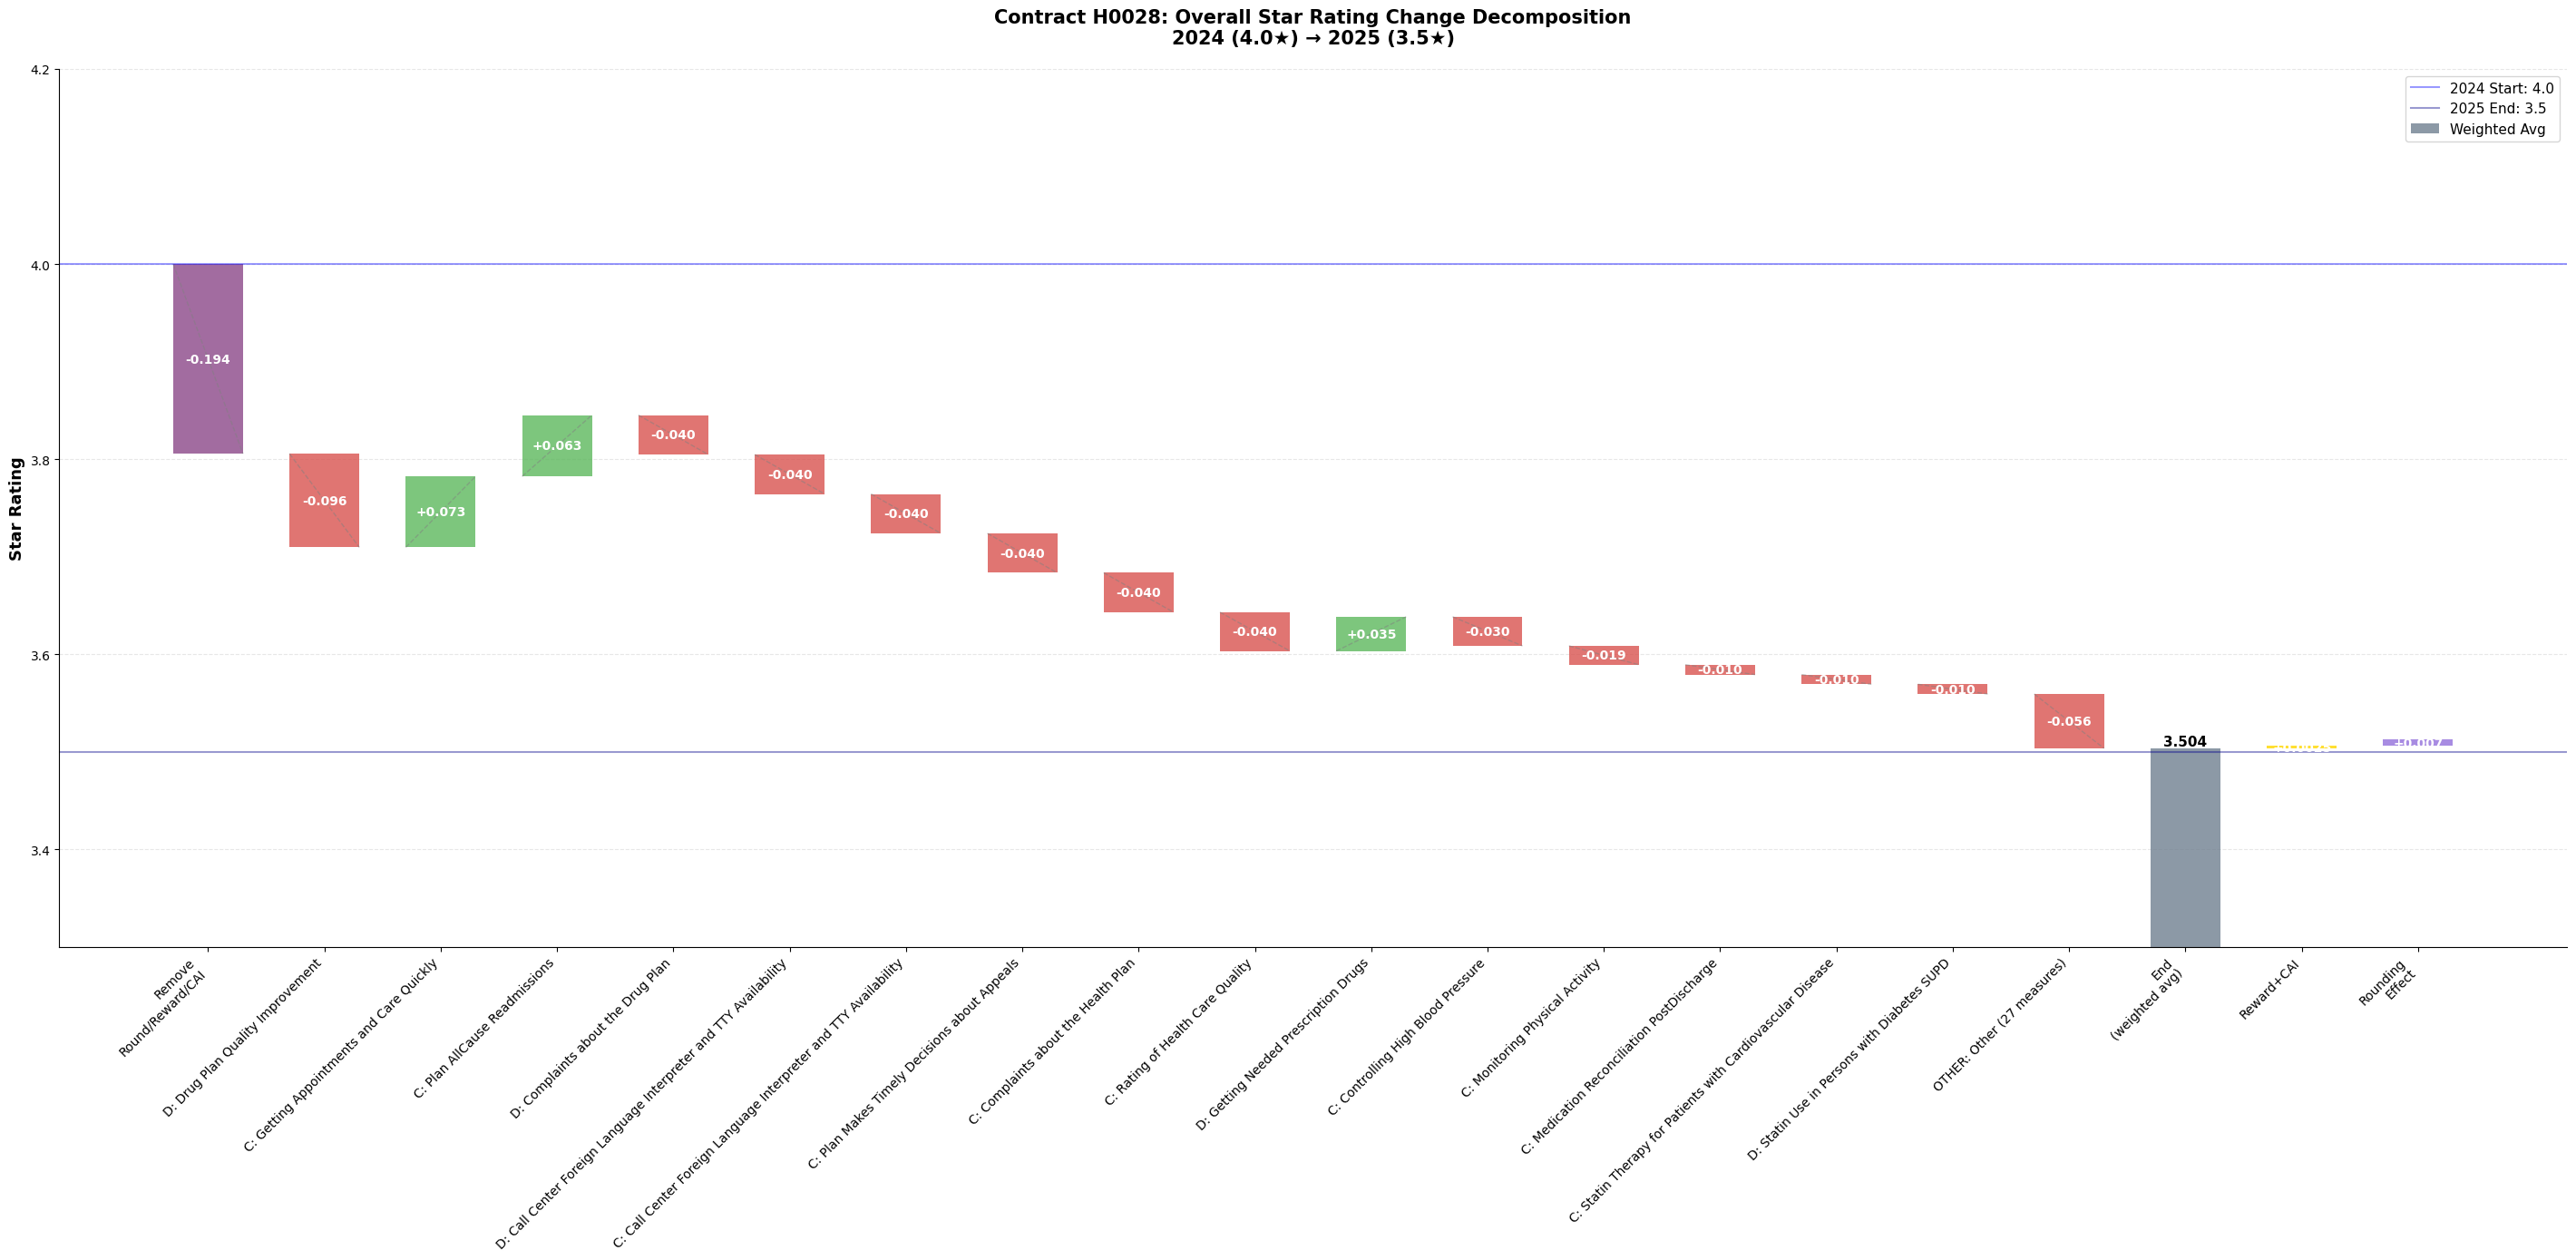

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns


def measure_contributions(y1_data, y2_data):
    """Split each measure's year-over-year effect into performance and weight-mix parts."""
    weight_sum_y1 = y1_data['Weight'].sum()
    weight_sum_y2 = y2_data['Weight'].sum()

    if weight_sum_y1 == 0 or weight_sum_y2 == 0:
        return None

    keep = ['measure_code', 'measure_name', 'star_rating_numeric', 'Weight']
    y1_measures = y1_data[keep].rename(columns={'star_rating_numeric': 'star_y1', 'Weight': 'weight_y1'})
    y2_measures = y2_data[keep].rename(columns={'star_rating_numeric': 'star_y2', 'Weight': 'weight_y2'})

    measures = y1_measures.merge(y2_measures, on=['measure_code', 'measure_name'], how='outer')
    measures = measures.fillna({'star_y1': 0, 'star_y2': 0, 'weight_y1': 0, 'weight_y2': 0})

    share_y1 = measures['weight_y1'] / weight_sum_y1
    share_y2 = measures['weight_y2'] / weight_sum_y2

    measures['performance'] = share_y1 * (measures['star_y2'] - measures['star_y1'])
    measures['mix'] = (share_y2 - share_y1) * measures['star_y1']
    measures['contribution'] = measures['performance'] + measures['mix']
    measures['star_change'] = measures['star_y2'] - measures['star_y1']
    measures['weight_change'] = measures['weight_y2'] - measures['weight_y1']

    return measures


def create_contract_waterfall(contract_id: str, df: pd.DataFrame, rating_type: str = 'Overall',
                              top_n: int = 15, show_start_bar: bool = True, show_end_bar: bool = True):
    """Waterfall from one year's contract star to the next.

    Flow: Y1 star -> Y1 weighted avg -> measure contributions -> Y2 weighted avg
    -> Y2 reward + CAI -> rounding -> Y2 star.
    """
    cols = RATING_COLUMNS[rating_type]

    contract_data = df[(df['contract_id'] == contract_id) & (df[cols['inclusion']] == True)].copy()
    if contract_data.empty:
        raise ValueError(f'No {rating_type} data for contract {contract_id}')

    years = sorted(contract_data['Year'].unique())
    if len(years) < 2:
        raise ValueError(f'Need two years of data for {contract_id}, found {years}')

    year_1 = years[0]
    year_2 = years[1]

    y1_data = contract_data[contract_data['Year'] == year_1]
    y2_data = contract_data[contract_data['Year'] == year_2]
    y1_contract = y1_data.iloc[0]
    y2_contract = y2_data.iloc[0]

    contract_star_y1 = y1_contract[cols['star']]
    contract_star_y2 = y2_contract[cols['star']]
    weighted_avg_y1 = y1_contract[cols['avg']]
    weighted_avg_y2 = y2_contract[cols['avg']]
    reward_factor_y2 = y2_contract[cols['reward']]

    cai_y2 = y2_contract[cols['cai']]
    if pd.isna(cai_y2):
        cai_y2 = 0.0

    # Steps either side of the measure contributions
    unround_reward_cai_y1 = weighted_avg_y1 - contract_star_y1
    reward_cai_combined_y2 = reward_factor_y2 + cai_y2
    rounding_y2 = contract_star_y2 - (weighted_avg_y2 + reward_cai_combined_y2)

    measures = measure_contributions(y1_data, y2_data)
    if measures is None:
        raise ValueError(f'Weight sum is zero for {contract_id} in {year_1} or {year_2}')

    measures['measure_label'] = measures['measure_code'].str[0] + ': ' + measures['measure_name']
    measures = measures[measures['contribution'] != 0]
    if measures.empty:
        raise ValueError(f'No measures changed for {contract_id} between {year_1} and {year_2}')

    measures['abs_contribution'] = measures['contribution'].abs()
    measures = measures.sort_values('abs_contribution', ascending=False)

    if len(measures) > top_n:
        top_measures = measures.head(top_n)
        other_measures = measures.iloc[top_n:]

        other_row = pd.DataFrame([{
            'measure_code': 'OTHER',
            'measure_name': f'Other ({len(other_measures)} measures)',
            'measure_label': f'OTHER: Other ({len(other_measures)} measures)',
            'contribution': other_measures['contribution'].sum(),
            'performance': other_measures['performance'].sum(),
            'mix': other_measures['mix'].sum()
        }])

        measures_display = pd.concat([top_measures, other_row], ignore_index=True)
    else:
        measures_display = measures.copy()

    measure_labels = measures_display['measure_label'].tolist()
    contributions = measures_display['contribution'].tolist()

    cumulative = [contract_star_y1, contract_star_y1 + unround_reward_cai_y1]
    for contribution in contributions:
        cumulative.append(cumulative[-1] + contribution)

    # Measures, plus the weighted average, reward and rounding bars
    n_bars = len(measure_labels) + 3
    if show_start_bar:
        n_bars += 1
    if show_end_bar:
        n_bars += 1

    fig, ax = plt.subplots(figsize=(max(24, n_bars * 1.5), 14))

    bar_labels = []
    x_positions = []
    bar_idx = 0
    cum_idx = 0

    if show_start_bar:
        bar_labels.append(f'Start\n{year_1}')
        x_positions.append(bar_idx)
        ax.bar(bar_idx, contract_star_y1, color='#4A90E2', alpha=0.8, width=0.6)
        ax.text(bar_idx, contract_star_y1 / 2, f'{contract_star_y1:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        bar_idx += 1

    bar_labels.append('Remove\nRound/Reward/CAI')
    x_positions.append(bar_idx)

    if unround_reward_cai_y1 > 0:
        bottom = cumulative[cum_idx]
        color = '#9370DB'
    else:
        bottom = cumulative[cum_idx + 1]
        color = '#8B4789'

    ax.bar(bar_idx, abs(unround_reward_cai_y1), bottom=bottom, color=color, alpha=0.8, width=0.6)
    ax.text(bar_idx, bottom + abs(unround_reward_cai_y1) / 2, f'{unround_reward_cai_y1:+.3f}',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bar_idx += 1
    cum_idx += 1

    for i, contribution in enumerate(contributions):
        bar_labels.append(measure_labels[i])
        x_positions.append(bar_idx)
        cum_idx += 1

        if contribution > 0:
            bottom = cumulative[cum_idx - 1]
            color = '#5CB85C'
        else:
            bottom = cumulative[cum_idx]
            color = '#D9534F'

        ax.bar(bar_idx, abs(contribution), bottom=bottom, color=color, alpha=0.8, width=0.6)
        ax.text(bar_idx, bottom + abs(contribution) / 2, f'{contribution:+.3f}',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        bar_idx += 1

    bar_labels.append('End\n(weighted avg)')
    x_positions.append(bar_idx)
    end_weighted = cumulative[-1]
    ax.bar(bar_idx, abs(end_weighted), bottom=min(0, end_weighted),
           color='#708090', alpha=0.8, width=0.6, label='Weighted Avg')
    ax.text(bar_idx, end_weighted, f'{end_weighted:.3f}',
            ha='center', va='bottom' if end_weighted > 0 else 'top', fontsize=11, fontweight='bold')
    bar_idx += 1

    bar_labels.append('Reward+CAI')
    x_positions.append(bar_idx)

    if reward_cai_combined_y2 > 0:
        bottom = end_weighted
        color = '#FFD700'
    else:
        bottom = end_weighted + reward_cai_combined_y2
        color = '#FFA500'

    ax.bar(bar_idx, abs(reward_cai_combined_y2), bottom=bottom, color=color, alpha=0.8, width=0.6)
    ax.text(bar_idx, bottom + abs(reward_cai_combined_y2) / 2, f'{reward_cai_combined_y2:+.4f}',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bar_idx += 1

    bar_labels.append('Rounding\nEffect')
    x_positions.append(bar_idx)
    end_after_reward_cai = end_weighted + reward_cai_combined_y2

    if rounding_y2 > 0:
        bottom = end_after_reward_cai
        color = '#9370DB'
    else:
        bottom = end_after_reward_cai + rounding_y2
        color = '#8B4789'

    ax.bar(bar_idx, abs(rounding_y2), bottom=bottom, color=color, alpha=0.8, width=0.6)
    ax.text(bar_idx, bottom + abs(rounding_y2) / 2, f'{rounding_y2:+.3f}',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bar_idx += 1

    if show_end_bar:
        bar_labels.append(f'End\n{year_2}')
        x_positions.append(bar_idx)
        ax.bar(bar_idx, contract_star_y2, color='#4A90E2', alpha=0.8, width=0.6)
        ax.text(bar_idx, contract_star_y2 / 2, f'{contract_star_y2:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        bar_idx += 1

    for i in range(len(cumulative) - 1):
        start_x = (1 if show_start_bar else 0) + i
        ax.plot([start_x - 0.3, start_x + 0.3], [cumulative[i], cumulative[i + 1]],
                color='gray', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Star Rating', fontsize=13, fontweight='bold')
    ax.set_title(f'Contract {contract_id}: {rating_type} Star Rating Change Decomposition\n'
                 f'{year_1} ({contract_star_y1:.1f}★) → {year_2} ({contract_star_y2:.1f}★)',
                 fontsize=15, fontweight='bold', pad=20)

    y_min = min(contract_star_y1, contract_star_y2, min(cumulative)) - 0.2
    y_max = max(contract_star_y1, contract_star_y2, max(cumulative)) + 0.2
    ax.set_ylim(y_min, y_max)

    ax.axhline(y=contract_star_y1, color='blue', linestyle='-', linewidth=1.5, alpha=0.4,
               label=f'{year_1} Start: {contract_star_y1:.1f}')
    ax.axhline(y=contract_star_y2, color='darkblue', linestyle='-', linewidth=1.5, alpha=0.4,
               label=f'{year_2} End: {contract_star_y2:.1f}')
    ax.legend(loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    sns.despine()
    plt.tight_layout()
    plt.show()

    return measures_display


use_contract = 'H0028'
waterfall_df = create_contract_waterfall(use_contract, final_df, rating_type='Overall', top_n=15,
                                         show_start_bar=False, show_end_bar=False)

In [84]:
waterfall_df.head()

,measure_code,measure_name,star_y1,weight_y1,star_y2,weight_y2,performance,mix,contribution,star_change,weight_change,measure_label,abs_contribution
0,D04,Drug Plan Quality Improvement,4.0,5.0,2.0,5.0,-0.092593,-0.003367,-0.095960,-2.0,0.0,D: Drug Plan Quality Improvement,0.095960
1,C20,Getting Appointments and Care Quickly,2.0,4.0,4.0,4.0,0.074074,-0.001347,0.072727,2.0,0.0,C: Getting Appointments and Care Quickly,0.072727
2,C15,Plan AllCause Readmissions,4.0,1.0,3.0,3.0,-0.009259,0.072054,0.062795,-1.0,2.0,C: Plan AllCause Readmissions,0.062795
3,D02,Complaints about the Drug Plan,5.0,4.0,4.0,4.0,-0.037037,-0.003367,-0.040404,-1.0,0.0,D: Complaints about the Drug Plan,0.040404
4,D01,Call Center Foreign Language Interpreter and T...,5.0,4.0,4.0,4.0,-0.037037,-0.003367,-0.040404,-1.0,0.0,D: Call Center Foreign Language Interpreter an...,0.040404


In [85]:
contract_row = pivoted_df[pivoted_df['contract_id'] == use_contract]

cols = ['Year', 'contract_id']
for col in contract_row.columns:
    if ('Overall' in col and 'Reward' in col) or 'Overall Summary' in col:
        cols.append(col)

contract_row[cols].head()

,Year,contract_id,Overall Summary,Reward Factor Overall,Overall Contract Star with Reward Factor,Overall Contract Star without Reward Factor,Overall Contract Star with Reward Factor and CAI,Overall Match with Reward,Overall Match without Reward,Overall Match with Reward and CAI
5,2024,H0028,4.0,0.2,4.0,4.0,4.0,True,True,True
6,2025,H0028,3.5,0.0,3.5,3.5,3.5,True,True,True
7,2026,H0028,3.5,0.0,3.5,3.5,3.5,True,True,True


## Enrollment

Membership by contract and year, plus the parent company each contract belongs
to. Needed to roll contracts up to company level.

In [86]:
enrollment_df = pd.read_csv(
    'data/other_data/medicare_advantage_and_partd_enrollment_by_contract_parent_mapped.csv',
    usecols=['Release Year', 'Contract Number', 'Enrollment', 'Current Owner'])

enrollment_df['Year'] = pd.to_datetime(enrollment_df['Release Year']).dt.year
enrollment_df = enrollment_df[enrollment_df['Year'] >= 2020]

enrollment_df = enrollment_df.groupby(
    ['Contract Number', 'Year', 'Current Owner'], as_index=False
).agg({'Enrollment': 'sum'})
enrollment_df = enrollment_df.rename(columns={'Contract Number': 'contract_id'})

enrollment_df.head(10)

,contract_id,Year,Current Owner,Enrollment
0,90091,2020,UMWA Health and Retirement Funds,46094.0
1,90091,2021,UMWA Health and Retirement Funds,44687.0
2,90091,2022,UMWA Health and Retirement Funds,43928.0
3,90091,2023,UMWA Health and Retirement Funds,42537.0
4,90091,2024,UMWA Health and Retirement Funds,41256.0
5,90091,2025,UMWA Health and Retirement Funds,39889.0
6,E0654,2020,IBT Voluntary Employee Benefits Trust,15292.0
7,E0654,2021,IBT Voluntary Employee Benefits Trust,14143.0
8,E0654,2022,IBT Voluntary Employee Benefits Trust,13778.0
9,E3014,2020,Commonwealth of PA Pub Schools Retirement System,95328.0


In [87]:
pivoted_df_with_enrollment = pivoted_df.merge(enrollment_df, on=['contract_id', 'Year'], how='left')

pivoted_df_with_enrollment[['contract_id', 'Year', 'Current Owner', 'Enrollment',
                            'Overall Contract Star with Reward Factor and CAI']].head(10)

,contract_id,Year,Current Owner,Enrollment,Overall Contract Star with Reward Factor and CAI
0,E3014,2024,Commonwealth of PA Pub Schools Retirement System,96792.0,NaN
1,E3014,2025,Commonwealth of PA Pub Schools Retirement System,95509.0,NaN
2,E3014,2026,NaN,NaN,NaN
3,H0022,2024,Centene Corporation,10206.0,NaN
4,H0022,2025,Centene Corporation,8616.0,NaN
5,H0028,2024,Humana Inc.,381180.0,4.0
6,H0028,2025,Humana Inc.,367209.0,3.5
7,H0028,2026,NaN,NaN,3.5
8,H0029,2024,Centene Corporation,0.0,NaN
9,H0029,2025,Centene Corporation,17534.0,NaN


## The same waterfall, one level up

Same idea at company level, with contracts in place of measures and enrollment
share in place of measure weight. Performance is a contract's own star moving;
mix is its share of the company's membership moving. Only contracts with a
rating and enrollment in both years are included, so the bridge closes.

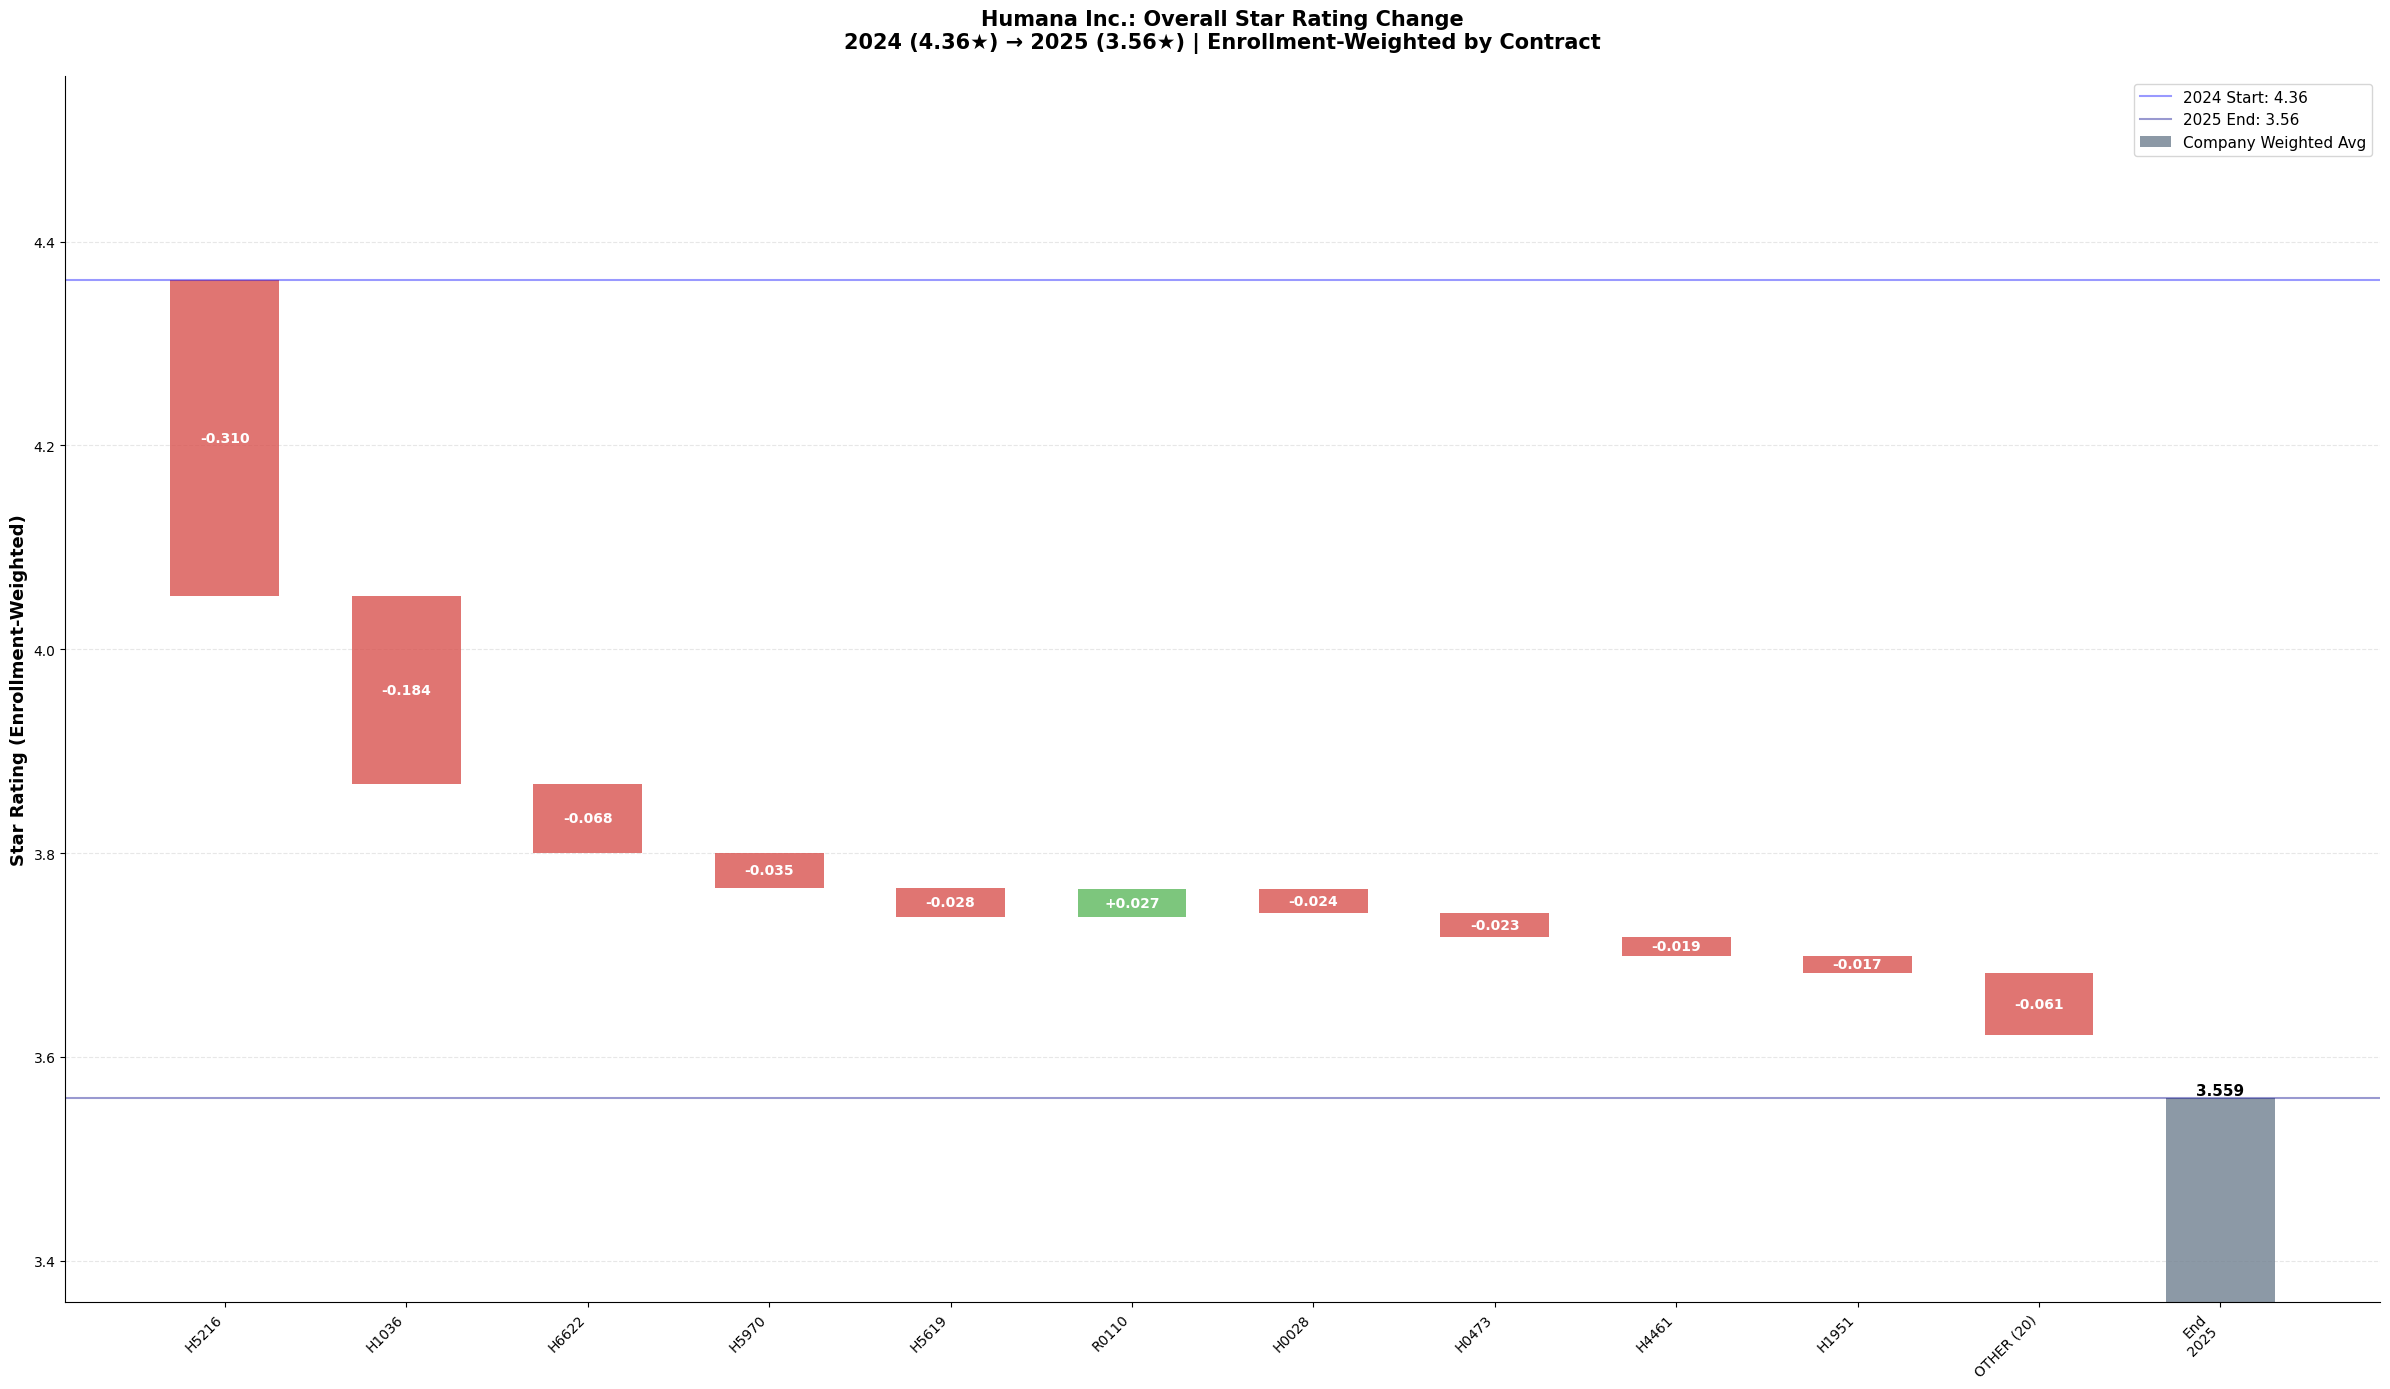

In [88]:
def create_company_waterfall(company_name: str, df: pd.DataFrame, rating_type: str = 'Overall',
                             year_1: int = 2024, year_2: int = 2025, top_n: int = 3,
                             show_start_bar: bool = False, show_end_bar: bool = False):
    """Enrollment-weighted waterfall of a company's star rating change across its contracts.

    Only contracts with enrollment and a star rating in both years are included.
    Returns the contract contributions and the contract ids shown individually.
    """
    star_col = RATING_COLUMNS[rating_type]['star']

    company_data = df[
        (df['Current Owner'] == company_name)
        & (df['Year'].isin([year_1, year_2]))
        & (df['Enrollment'] > 0)
        & (df[star_col].notna())
    ].copy()

    if company_data.empty:
        raise ValueError(f'No data found for {company_name}')

    # Share of the company's enrolment each contract holds in its year
    year_totals = company_data.groupby('Year')['Enrollment'].transform('sum')
    if (year_totals == 0).any():
        raise ValueError(f'Zero enrollment for {company_name} in {year_1} or {year_2}')

    company_data['Enrollment_Pct'] = company_data['Enrollment'] / year_totals

    y1_data = company_data[company_data['Year'] == year_1]
    y2_data = company_data[company_data['Year'] == year_2]

    company_star_y1 = (y1_data[star_col] * y1_data['Enrollment_Pct']).sum()
    company_star_y2 = (y2_data[star_col] * y2_data['Enrollment_Pct']).sum()

    y1_contracts = y1_data[['contract_id', 'Contract Name', star_col, 'Enrollment', 'Enrollment_Pct']].rename(
        columns={star_col: 'star_y1', 'Enrollment': 'enrollment_y1', 'Enrollment_Pct': 'pct_y1'})
    y2_contracts = y2_data[['contract_id', star_col, 'Enrollment', 'Enrollment_Pct']].rename(
        columns={star_col: 'star_y2', 'Enrollment': 'enrollment_y2', 'Enrollment_Pct': 'pct_y2'})

    # Inner join keeps only contracts present in both years
    contracts = y1_contracts.merge(y2_contracts, on='contract_id', how='inner')

    contracts['performance'] = contracts['pct_y1'] * (contracts['star_y2'] - contracts['star_y1'])
    contracts['mix'] = (contracts['pct_y2'] - contracts['pct_y1']) * contracts['star_y1']
    contracts['contribution'] = contracts['performance'] + contracts['mix']
    contracts = contracts[contracts['contribution'] != 0]

    if contracts.empty:
        raise ValueError(f'No contracts changed for {company_name} between {year_1} and {year_2}')

    contracts['abs_contribution'] = contracts['contribution'].abs()
    contracts = contracts.sort_values('abs_contribution', ascending=False)
    contracts['contract_label'] = contracts['contract_id']

    if len(contracts) > top_n:
        top_contracts = contracts.head(top_n)
        other_contracts = contracts.iloc[top_n:]

        other_row = pd.DataFrame([{
            'contract_id': 'OTHER',
            'Contract Name': f'Other ({len(other_contracts)} contracts)',
            'contract_label': f'OTHER ({len(other_contracts)})',
            'contribution': other_contracts['contribution'].sum(),
            'performance': other_contracts['performance'].sum(),
            'mix': other_contracts['mix'].sum()
        }])

        contracts_display = pd.concat([top_contracts, other_row], ignore_index=True)
        displayed_contracts = top_contracts['contract_id'].tolist()
    else:
        contracts_display = contracts.copy()
        displayed_contracts = contracts['contract_id'].tolist()

    contract_labels = contracts_display['contract_label'].tolist()
    contributions = contracts_display['contribution'].tolist()

    cumulative = [company_star_y1]
    for contribution in contributions:
        cumulative.append(cumulative[-1] + contribution)

    # Contracts, plus the closing weighted average bar
    n_bars = len(contract_labels) + 1
    if show_start_bar:
        n_bars += 1
    if show_end_bar:
        n_bars += 1

    fig, ax = plt.subplots(figsize=(max(24, n_bars * 1.5), 14))

    bar_labels = []
    x_positions = []
    bar_idx = 0

    if show_start_bar:
        bar_labels.append(f'Start\n{year_1}')
        x_positions.append(bar_idx)
        ax.bar(bar_idx, company_star_y1, color='#4A90E2', alpha=0.8, width=0.6)
        ax.text(bar_idx, company_star_y1 / 2, f'{company_star_y1:.3f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        bar_idx += 1

    for i, contribution in enumerate(contributions):
        bar_labels.append(contract_labels[i])
        x_positions.append(bar_idx)

        if contribution > 0:
            bottom = cumulative[i]
            color = '#5CB85C'
        else:
            bottom = cumulative[i + 1]
            color = '#D9534F'

        ax.bar(bar_idx, abs(contribution), bottom=bottom, color=color, alpha=0.8, width=0.6)
        ax.text(bar_idx, bottom + abs(contribution) / 2, f'{contribution:+.3f}',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        bar_idx += 1

    bar_labels.append(f'End\n{year_2}')
    x_positions.append(bar_idx)
    ax.bar(bar_idx, abs(company_star_y2), bottom=min(0, company_star_y2),
           color='#708090', alpha=0.8, width=0.6, label='Company Weighted Avg')
    ax.text(bar_idx, company_star_y2, f'{company_star_y2:.3f}',
            ha='center', va='bottom' if company_star_y2 > 0 else 'top', fontsize=11, fontweight='bold')
    bar_idx += 1

    if show_end_bar:
        bar_labels.append(f'End\n{year_2}')
        x_positions.append(bar_idx)
        ax.bar(bar_idx, company_star_y2, color='#4A90E2', alpha=0.8, width=0.6)
        ax.text(bar_idx, company_star_y2 / 2, f'{company_star_y2:.3f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        bar_idx += 1

    ax.set_xticks(x_positions)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Star Rating (Enrollment-Weighted)', fontsize=13, fontweight='bold')
    ax.set_title(f'{company_name}: {rating_type} Star Rating Change\n'
                 f'{year_1} ({company_star_y1:.2f}★) → {year_2} ({company_star_y2:.2f}★) '
                 f'| Enrollment-Weighted by Contract',
                 fontsize=15, fontweight='bold', pad=20)

    y_min = min(company_star_y1, company_star_y2, min(cumulative)) - 0.2
    y_max = max(company_star_y1, company_star_y2, max(cumulative)) + 0.2
    ax.set_ylim(y_min, y_max)

    ax.axhline(y=company_star_y1, color='blue', linestyle='-', linewidth=1.5, alpha=0.4,
               label=f'{year_1} Start: {company_star_y1:.2f}')
    ax.axhline(y=company_star_y2, color='darkblue', linestyle='-', linewidth=1.5, alpha=0.4,
               label=f'{year_2} End: {company_star_y2:.2f}')
    ax.legend(loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    sns.despine()
    plt.tight_layout()
    plt.show()

    return contracts_display, displayed_contracts


company = 'Humana Inc.'
company_waterfall_df, top_n_contracts = create_company_waterfall(
    company,
    pivoted_df_with_enrollment,
    rating_type='Overall',
    year_1=2024,
    year_2=2025,
    top_n=10
)

In [89]:
company_waterfall_df[['contract_id', 'Contract Name', 'star_y1', 'star_y2',
                      'performance', 'mix', 'contribution']]

,contract_id,Contract Name,star_y1,star_y2,performance,mix,contribution
0,H5216,HUMANA INSURANCE COMPANY,4.5,3.5,-0.446786,0.136540,-0.310247
1,H1036,"HUMANA MEDICAL PLAN, INC.",5.0,3.5,-0.170855,-0.013365,-0.184221
2,H6622,HUMANA WI HEALTH ORGANIZATION INSURANCE CORP,4.0,3.5,-0.032100,-0.035523,-0.067623
3,H5970,HUMANA INSURANCE COMPANY OF NEW YORK,3.5,3.5,0.000000,-0.034662,-0.034662
4,H5619,"ARCADIAN HEALTH PLAN, INC.",4.0,3.5,-0.041149,0.013071,-0.028078
5,R0110,HUMANA INSURANCE COMPANY,4.5,3.5,-0.001510,0.028964,0.027454
6,H0028,"CHA HMO, INC.",4.0,3.5,-0.030794,0.006555,-0.024238
7,H0473,HUMANA INSURANCE COMPANY OF KENTUCKY,3.5,3.5,0.000000,-0.022929,-0.022929
8,H4461,CARITEN HEALTH PLAN INC.,5.0,4.5,-0.013842,-0.004913,-0.018755
9,H1951,"HUMANA HEALTH BENEFIT PLAN OF LOUISIANA, INC.",4.5,4.0,-0.014152,-0.002709,-0.016861


The three contracts that moved the company most, broken back down measure by
measure.

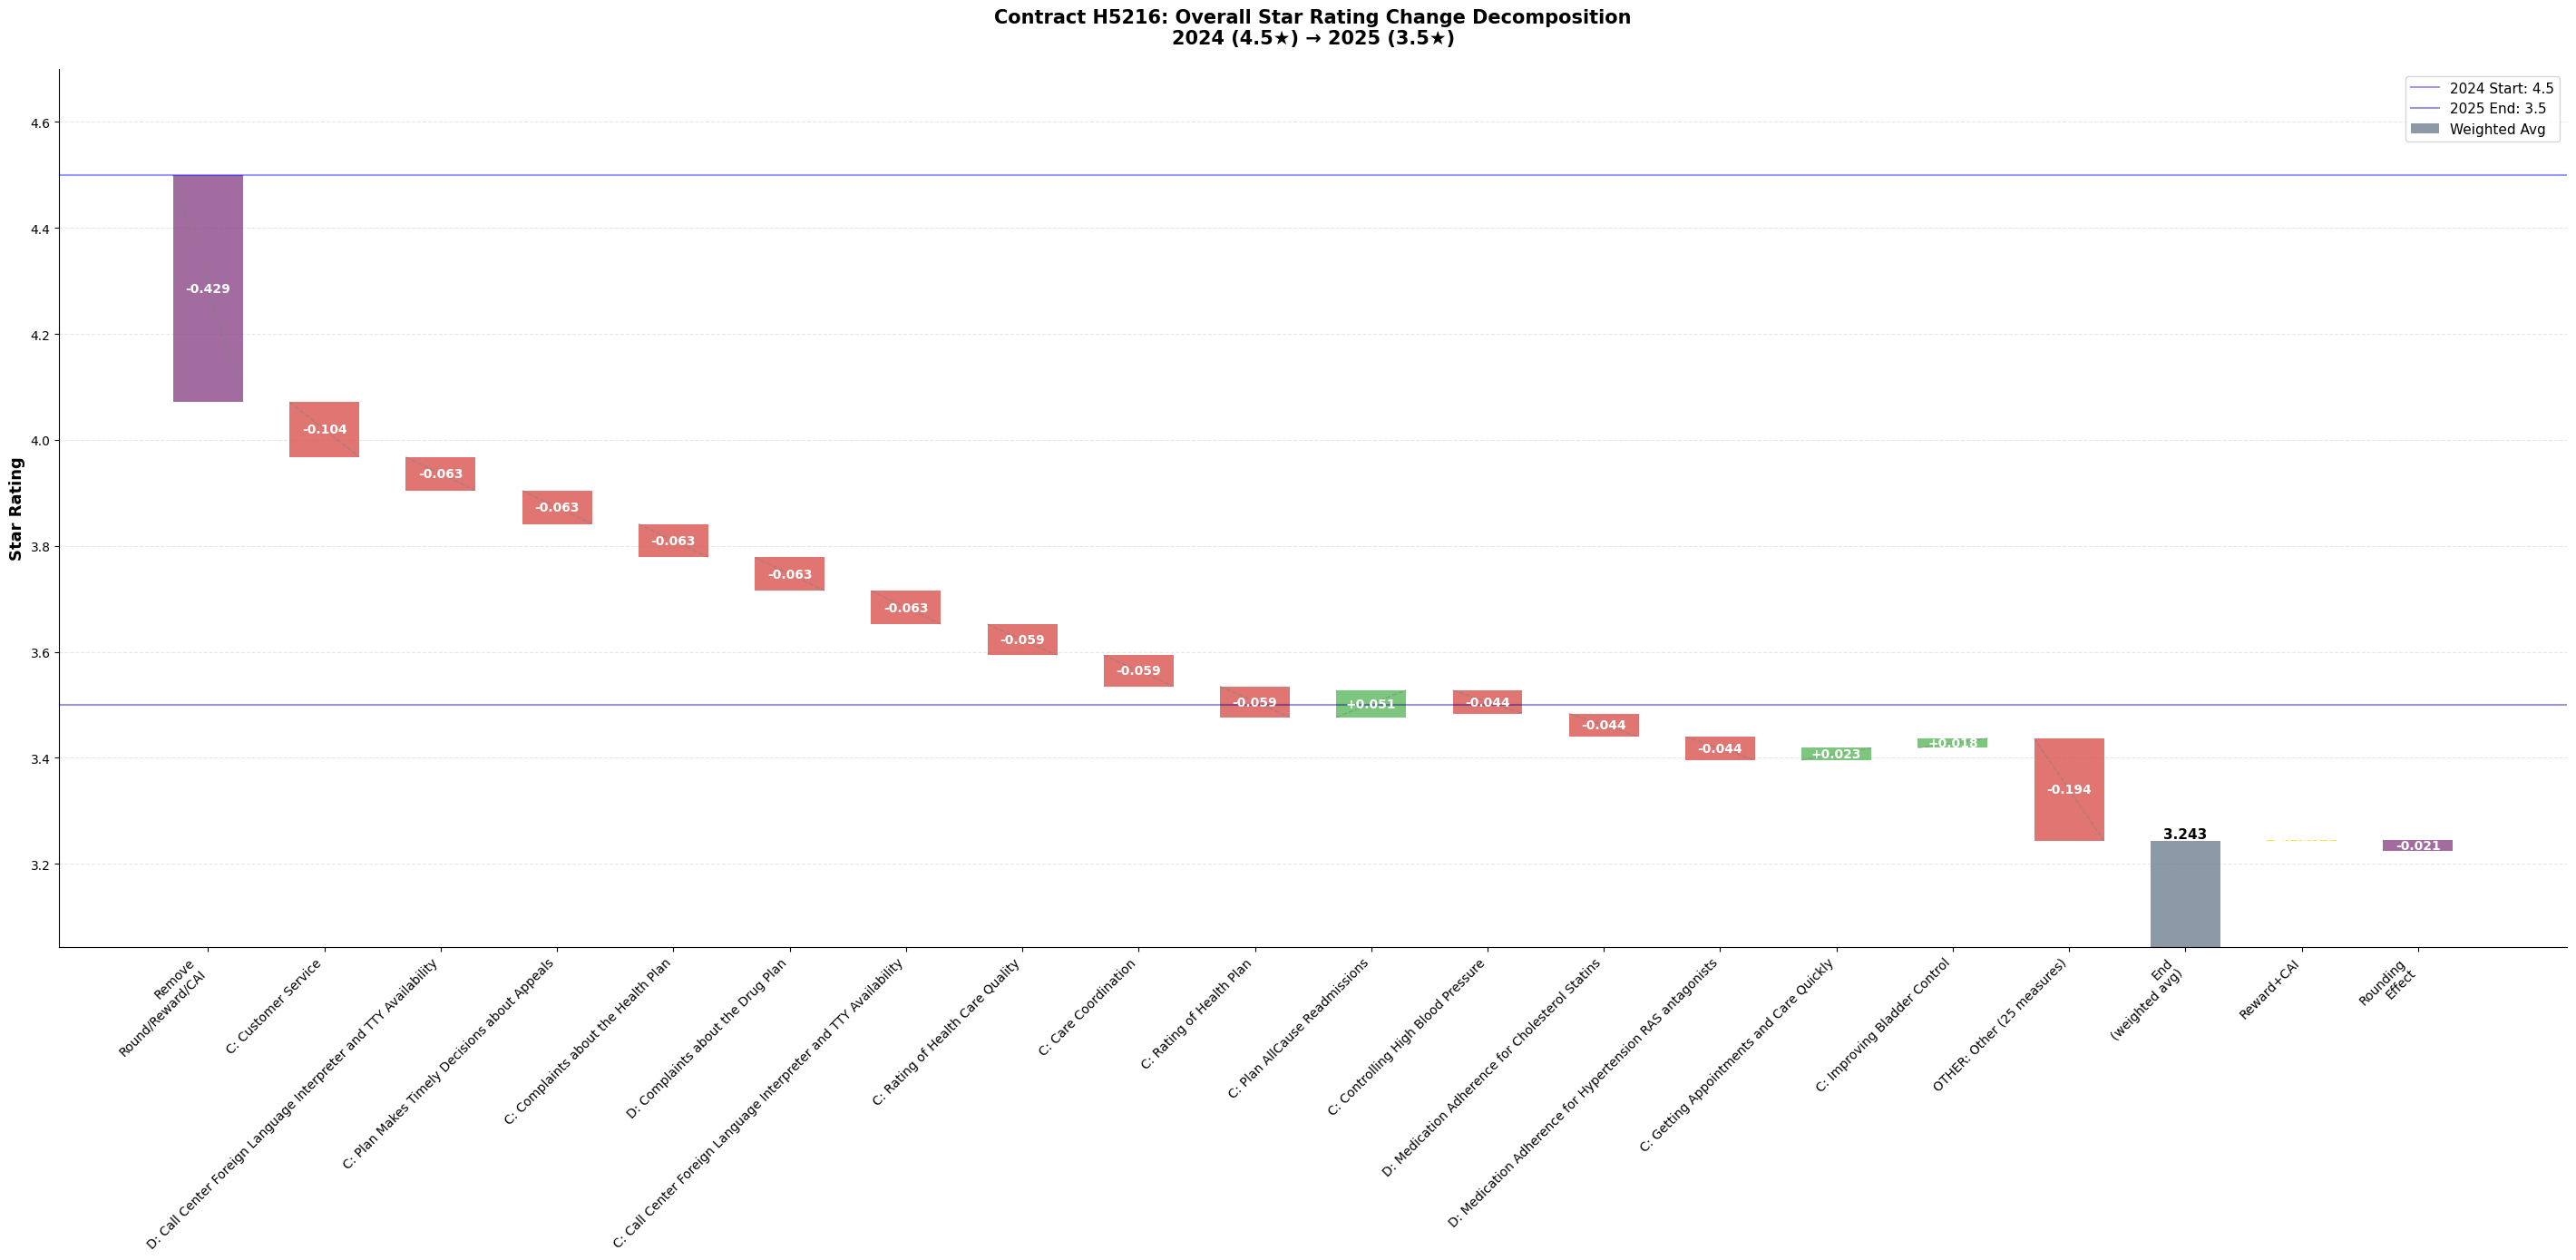

In [90]:
waterfall_1 = create_contract_waterfall(top_n_contracts[0], final_df, rating_type='Overall',
                                        top_n=15, show_start_bar=False, show_end_bar=False)

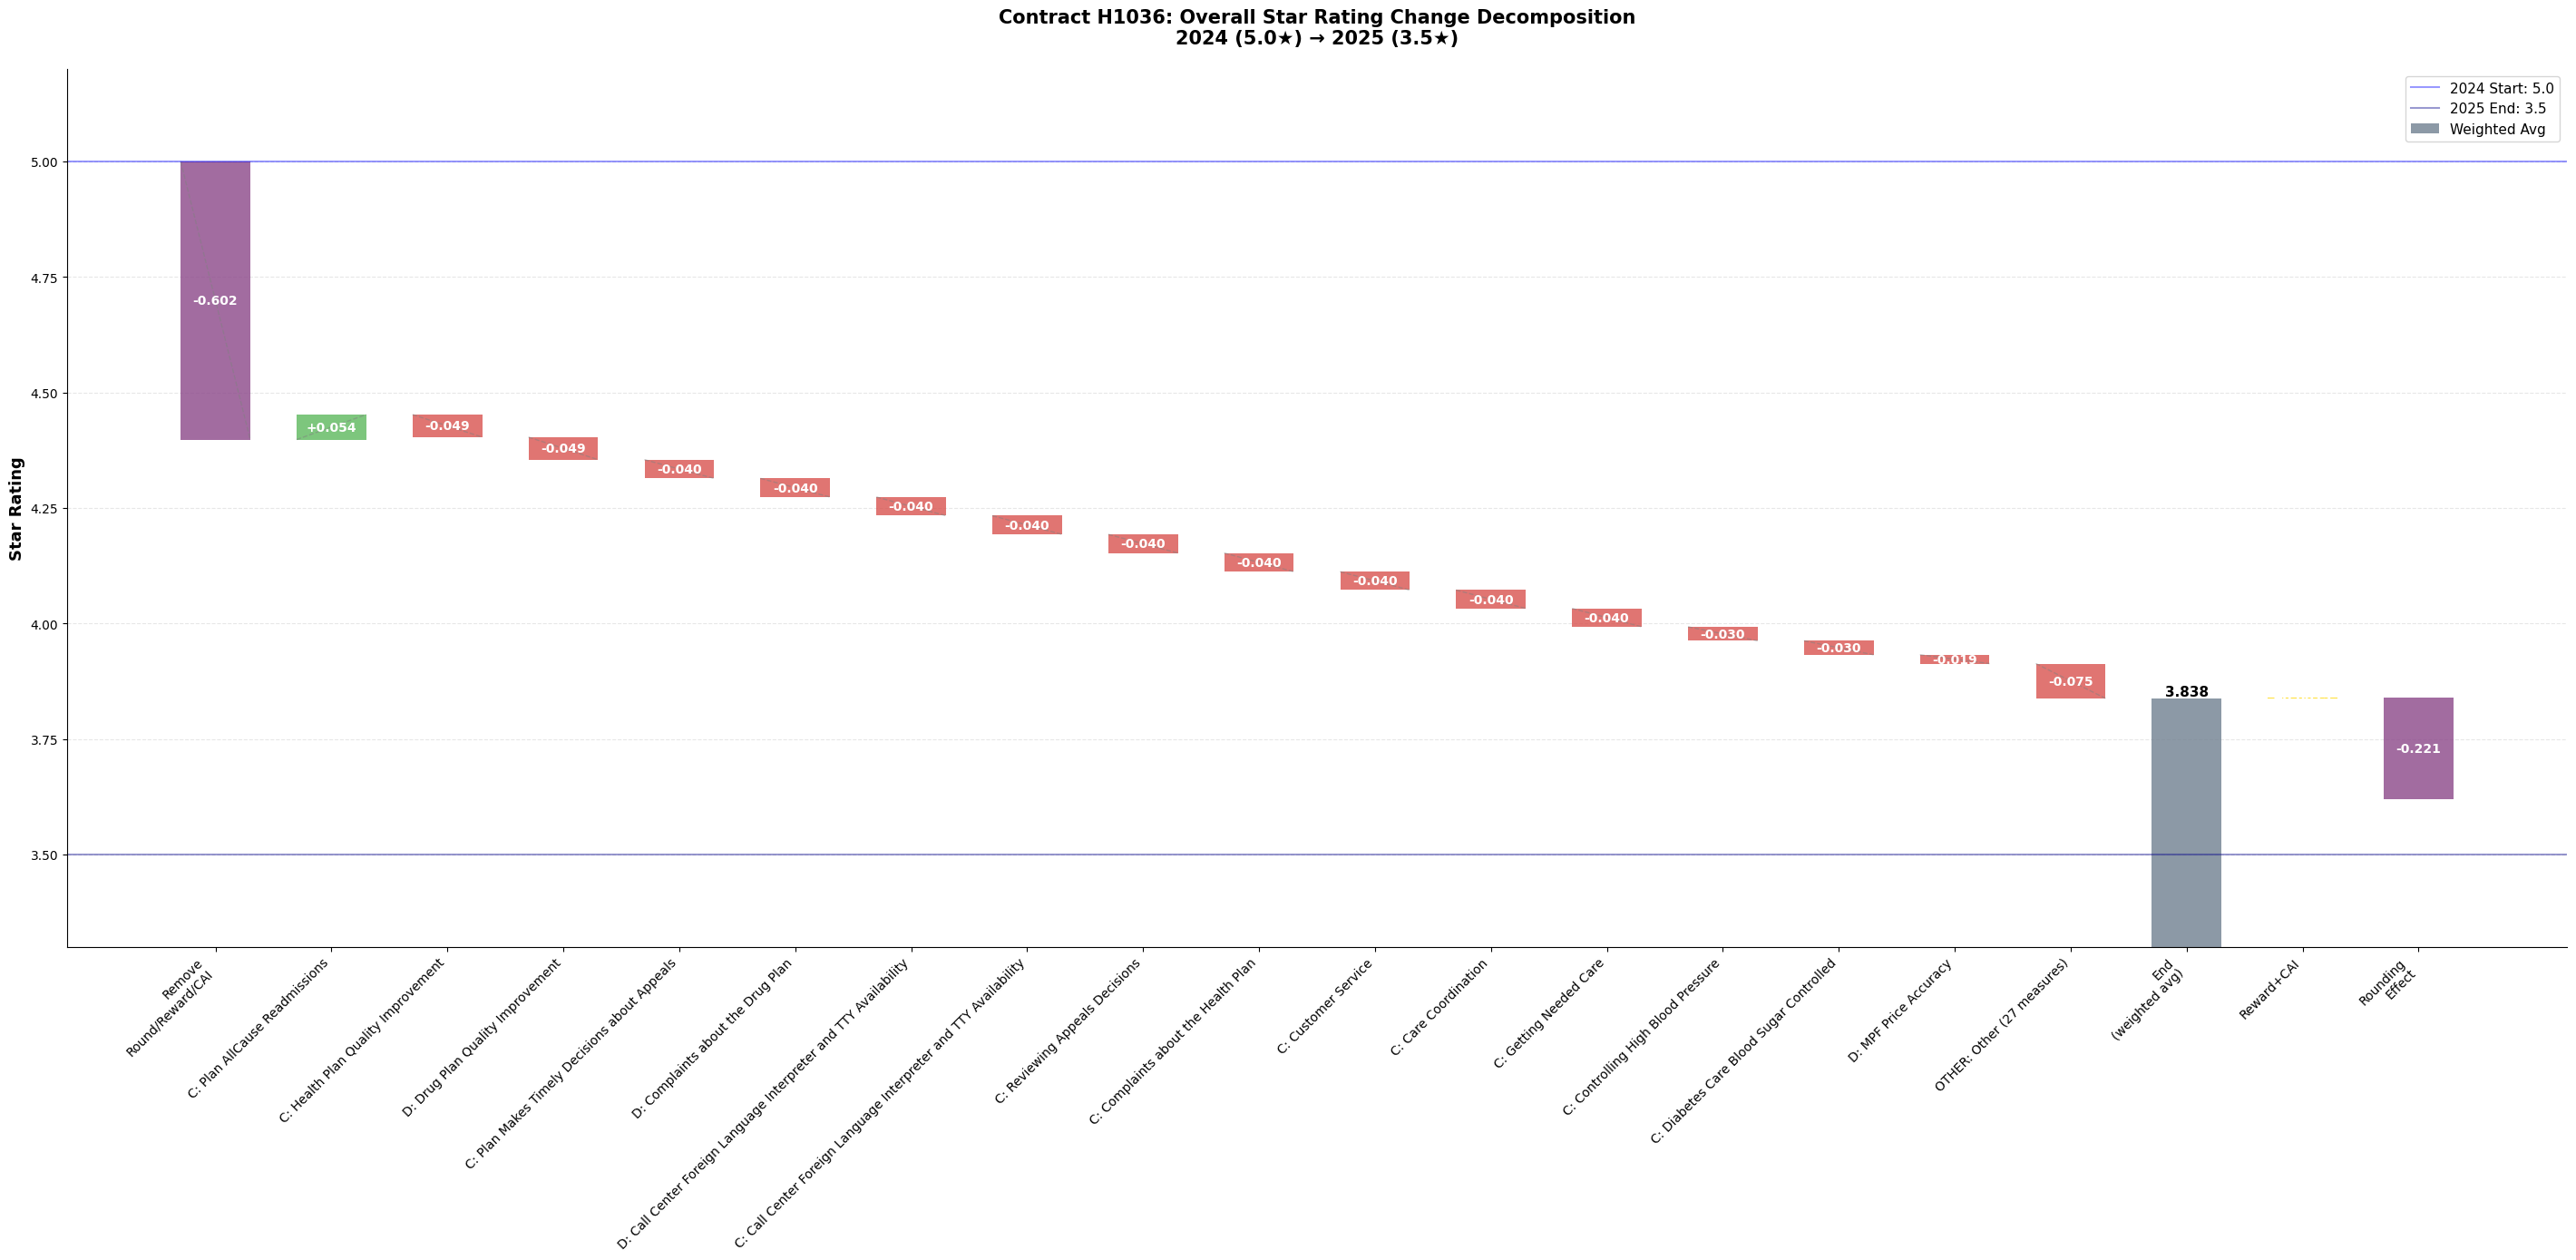

In [91]:
waterfall_2 = create_contract_waterfall(top_n_contracts[1], final_df, rating_type='Overall',
                                        top_n=15, show_start_bar=False, show_end_bar=False)

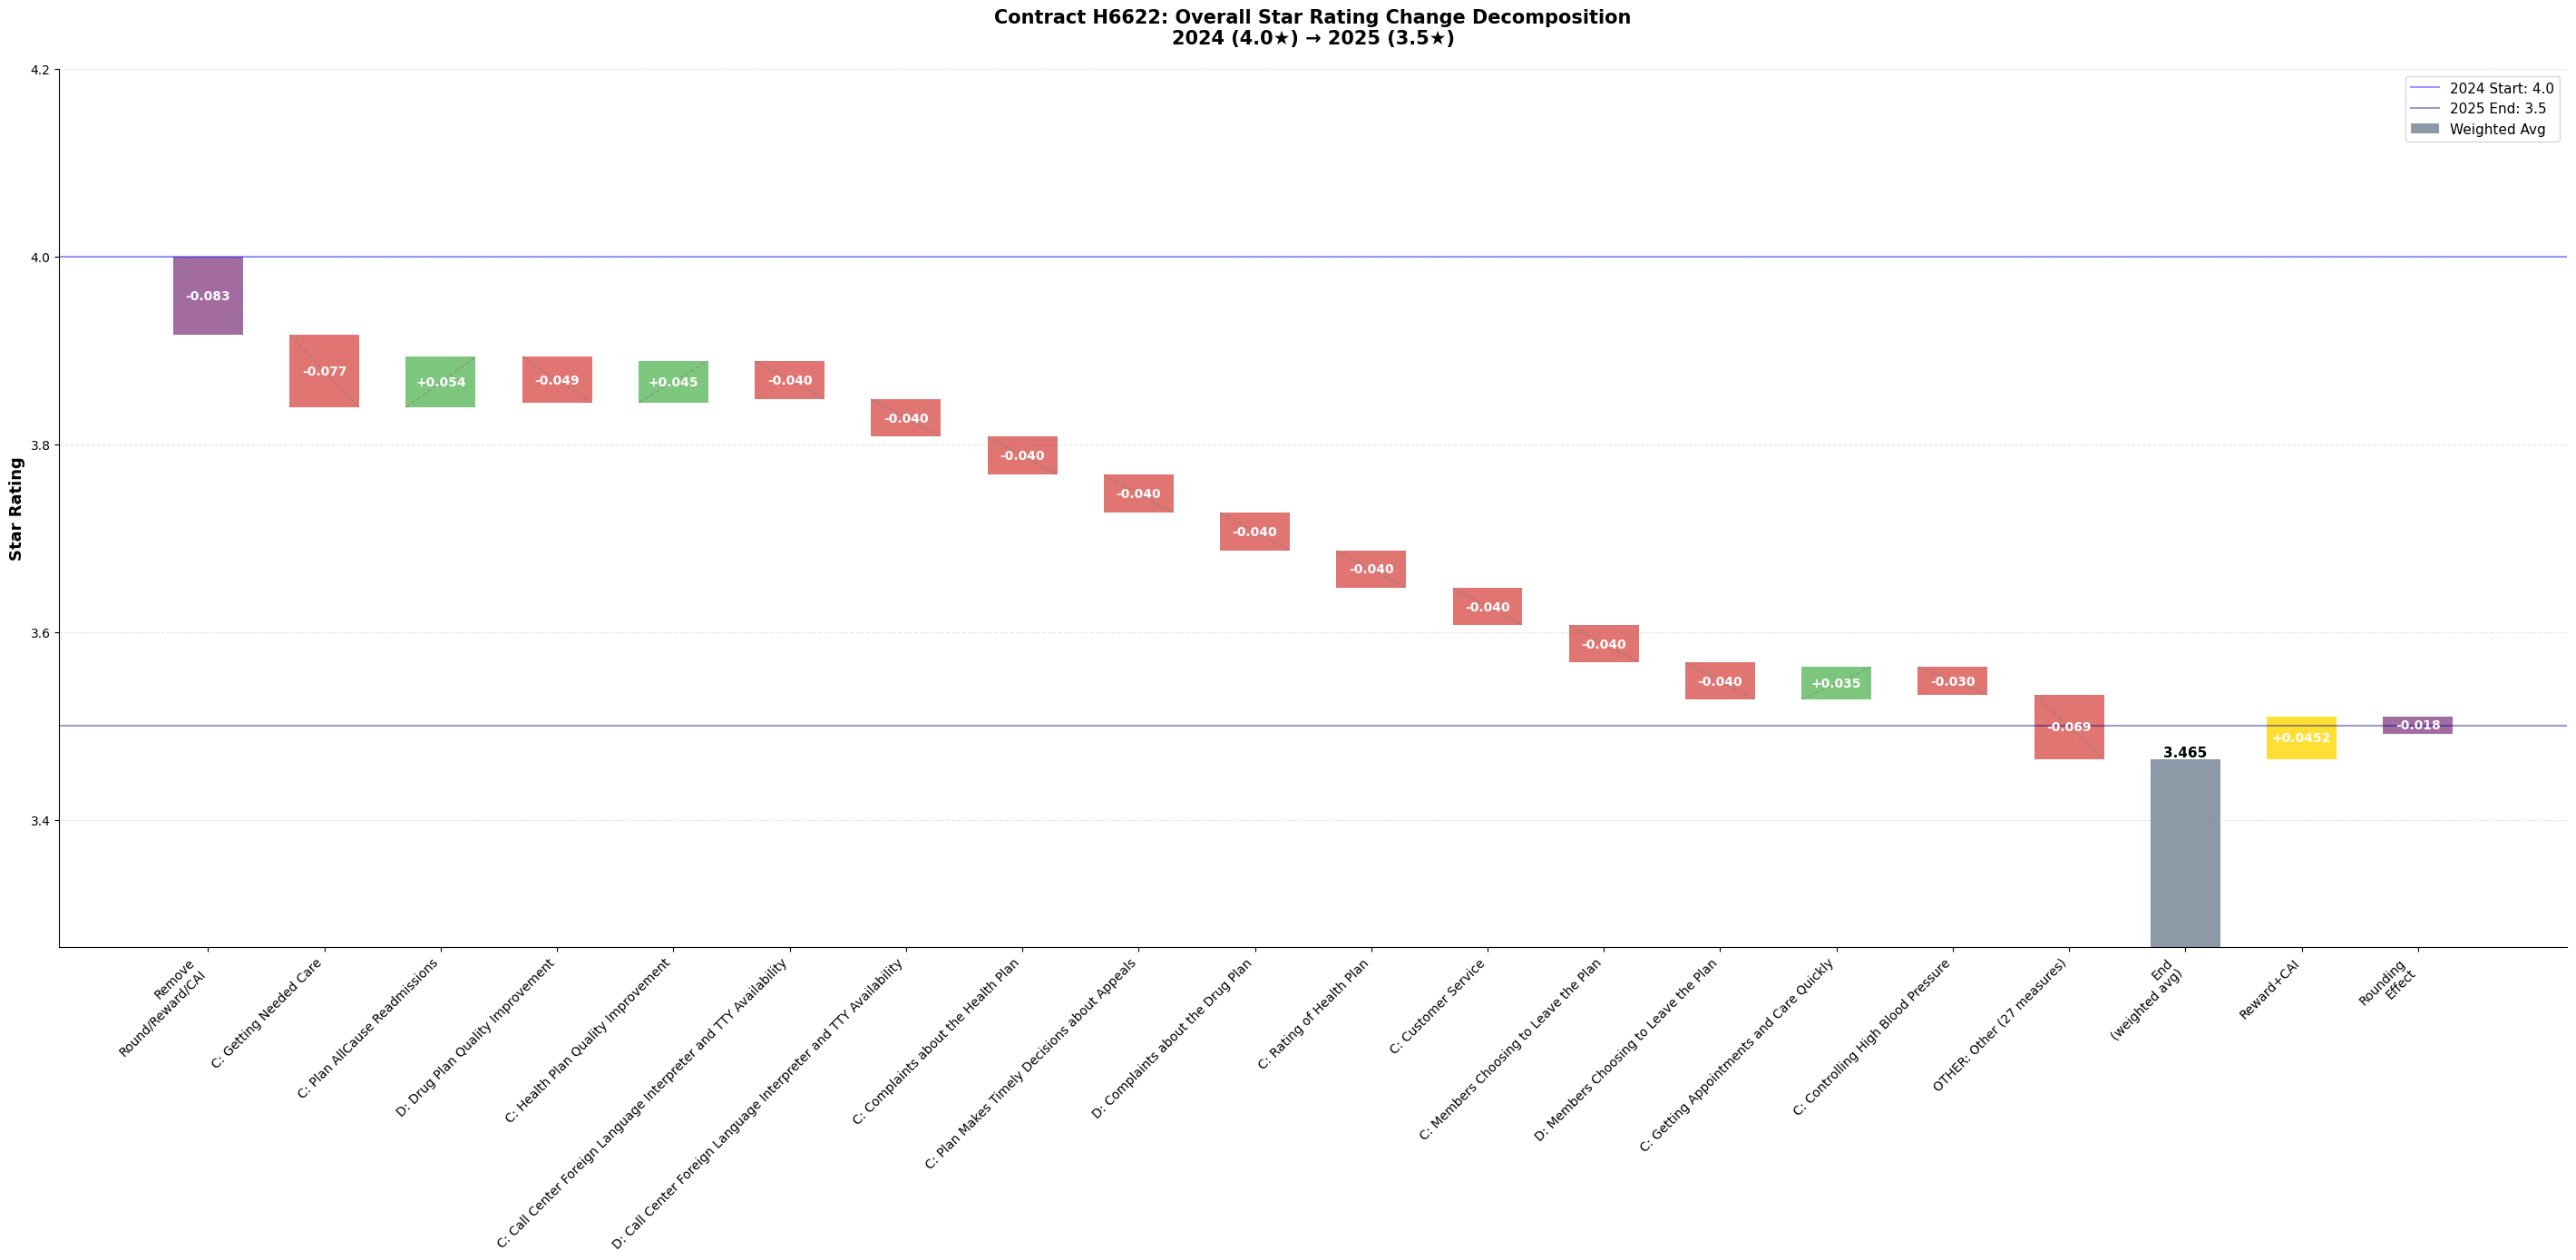

In [92]:
waterfall_3 = create_contract_waterfall(top_n_contracts[2], final_df, rating_type='Overall',
                                        top_n=15, show_start_bar=False, show_end_bar=False)

## Contributions for every contract

The waterfall decomposition run across every contract, year pair and rating
type, rather than one chart at a time, and written out for use elsewhere.

In [93]:
final_df = final_df.merge(enrollment_df, on=['Year', 'contract_id'], how='left')

In [94]:
def calculate_all_contributions(df: pd.DataFrame, rating_types=('Part C', 'Part D', 'Overall')):
    """Measure-level year-over-year contributions for every contract and rating type."""
    results = []

    for contract_id, contract_data in df.groupby('contract_id'):
        years = sorted(contract_data['Year'].unique())

        for i in range(len(years) - 1):
            year_1 = years[i]
            year_2 = years[i + 1]

            for rating_type in rating_types:
                cols = RATING_COLUMNS[rating_type]
                rating_data = contract_data[contract_data[cols['inclusion']] == True]

                y1_data = rating_data[rating_data['Year'] == year_1]
                y2_data = rating_data[rating_data['Year'] == year_2]
                if y1_data.empty or y2_data.empty:
                    continue

                measures = measure_contributions(y1_data, y2_data)
                if measures is None:
                    continue

                y1_contract = y1_data.iloc[0]
                y2_contract = y2_data.iloc[0]

                contract_star_y1 = y1_contract[cols['star']]
                contract_star_y2 = y2_contract[cols['star']]
                weighted_avg_y1 = y1_contract[cols['avg']]
                weighted_avg_y2 = y2_contract[cols['avg']]
                reward_factor_y1 = y1_contract[cols['reward']]
                reward_factor_y2 = y2_contract[cols['reward']]

                cai_y1 = y1_contract[cols['cai']]
                cai_y2 = y2_contract[cols['cai']]
                if pd.isna(cai_y1):
                    cai_y1 = 0.0
                if pd.isna(cai_y2):
                    cai_y2 = 0.0

                measures['contract_id'] = contract_id
                measures['year_from'] = year_1
                measures['year_to'] = year_2
                measures['rating_type'] = rating_type

                measures['contract_star_y1'] = contract_star_y1
                measures['contract_star_y2'] = contract_star_y2
                measures['total_star_change'] = contract_star_y2 - contract_star_y1

                measures['weighted_avg_y1'] = weighted_avg_y1
                measures['weighted_avg_y2'] = weighted_avg_y2
                measures['weighted_avg_change'] = weighted_avg_y2 - weighted_avg_y1

                measures['reward_factor_y1'] = reward_factor_y1
                measures['reward_factor_y2'] = reward_factor_y2
                measures['reward_factor_change'] = reward_factor_y2 - reward_factor_y1

                measures['cai_y1'] = cai_y1
                measures['cai_y2'] = cai_y2
                measures['cai_change'] = cai_y2 - cai_y1

                measures['weighted_avg_plus_reward_y1'] = weighted_avg_y1 + reward_factor_y1
                measures['weighted_avg_plus_reward_y2'] = weighted_avg_y2 + reward_factor_y2
                measures['weighted_avg_plus_reward_cai_y1'] = weighted_avg_y1 + reward_factor_y1 + cai_y1
                measures['weighted_avg_plus_reward_cai_y2'] = weighted_avg_y2 + reward_factor_y2 + cai_y2

                results.append(measures)

    if not results:
        return None

    return pd.concat(results, ignore_index=True)


contribution_df = calculate_all_contributions(final_df)

contribution_df.shape

(112610, 31)

In [95]:
slim_contribution_output = contribution_df[[
    'contract_id',
    'year_from',
    'year_to',
    'rating_type',
    'measure_code',
    'measure_name',

    'star_y1',
    'star_y2',
    'star_change',

    'weight_y1',
    'weight_y2',
    'weight_change',

    'contribution',
    'performance',
    'mix',

    'contract_star_y1',
    'contract_star_y2',
    'total_star_change',

    'weighted_avg_y1',
    'weighted_avg_y2',
    'weighted_avg_change',

    'reward_factor_y1',
    'reward_factor_y2',
    'reward_factor_change',

    'cai_y1',
    'cai_y2',
    'cai_change',

    'weighted_avg_plus_reward_y1',
    'weighted_avg_plus_reward_y2',
    'weighted_avg_plus_reward_cai_y1',
    'weighted_avg_plus_reward_cai_y2'
]].copy()

slim_contribution_output = slim_contribution_output.sort_values(
    ['contract_id', 'rating_type', 'year_to', 'contribution'],
    ascending=[True, True, True, False]
)

slim_contribution_output.head(10)

,contract_id,year_from,year_to,rating_type,measure_code,measure_name,star_y1,star_y2,star_change,weight_y1,...,reward_factor_y1,reward_factor_y2,reward_factor_change,cai_y1,cai_y2,cai_change,weighted_avg_plus_reward_y1,weighted_avg_plus_reward_y2,weighted_avg_plus_reward_cai_y1,weighted_avg_plus_reward_cai_y2
9,E3014,2024,2025,Overall,D02,Complaints about the Drug Plan,5.0,5.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
10,E3014,2024,2025,Overall,D04,Drug Plan Quality Improvement,4.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
11,E3014,2024,2025,Overall,D05,Rating of Drug Plan,5.0,5.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
12,E3014,2024,2025,Overall,D06,Getting Needed Prescription Drugs,5.0,5.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
13,E3014,2024,2025,Overall,D08,Medication Adherence for Diabetes Medications,4.0,4.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
14,E3014,2024,2025,Overall,D09,Medication Adherence for Hypertension RAS anta...,4.0,4.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
15,E3014,2024,2025,Overall,D10,Medication Adherence for Cholesterol Statins,4.0,4.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
16,E3014,2024,2025,Overall,D11,MTM Program Completion Rate for CMR,4.0,4.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
17,E3014,2024,2025,Overall,D12,Statin Use in Persons with Diabetes SUPD,4.0,4.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
31,E3014,2025,2026,Overall,D08,Medication Adherence for Diabetes Medications,4.0,4.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [97]:
slim_contribution_output.to_csv('output/slim_contribution_output.csv', index=False)